In [1]:
import awswrangler as wr
import boto3
import pandas as pd
import numpy as np
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("/Users/daniellai/MSDS_2026/AQI-MLops/.env"))

session = boto3.Session(
    region_name=os.environ.get("AWS_DEFAULT_REGION", "us-east-1"),
    aws_access_key_id=os.environ.get("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.environ.get("AWS_SECRET_ACCESS_KEY"),
    aws_session_token=os.environ.get("AWS_SESSION_TOKEN"),
)

# awswrangler downloads result as a single S3 file — no 999-row page cap
sql = """
SELECT
    timestamp, city, city_slug,
    aqi, co, no, no2, o3, so2, pm2_5, pm10, nh3,
    source
FROM aqi_db.aqi_unified
ORDER BY city_slug ASC, timestamp ASC
"""

raw = wr.athena.read_sql_query(
    sql=sql,
    database="aqi_db",
    s3_output="s3://weather-bulk/athena-results/",
    boto3_session=session,
    ctas_approach=False,
)

# Cast aqi to int then merge class 6 → 5
# OWM occasionally emits a 6 which is not a valid AQI level (scale is 1–5).
# Treating it as "Very Poor" (5) is the conservative, correct choice.
raw["aqi"] = pd.to_numeric(raw["aqi"], errors="coerce").astype("Int64")
n_class6 = (raw["aqi"] == 6).sum()
raw["aqi"] = raw["aqi"].clip(upper=5)   # 6 → 5; leaves 1–5 untouched
print(f"AQI class 6 rows merged into class 5 : {n_class6:,}")

print(f"\nRows   : {len(raw):,}")
print(f"Cities : {raw['city_slug'].nunique()}")
print(f"Range  : {raw['timestamp'].min()}  →  {raw['timestamp'].max()}")
print(f"\nAQI class distribution after merge:")
print(raw["aqi"].value_counts().sort_index().to_dict())
raw.head(3)


AQI class 6 rows merged into class 5 : 11

Rows   : 868,983
Cities : 99
Range  : 2025-03-20 00:00:00  →  2026-04-03 18:24:49

AQI class distribution after merge:
{np.int64(1): 258062, np.int64(2): 291807, np.int64(3): 157821, np.int64(4): 71489, np.int64(5): 89804}


,timestamp,city,city_slug,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,source
0,2025-03-20 00:00:00,Abidjan,abidjan,2,680.92,0.0,4.16,22.71,3.78,7.95,22.94,8.99,pipeline
1,2025-03-20 01:00:00,Abidjan,abidjan,2,674.25,0.0,3.64,22.53,3.61,7.95,23.06,8.11,pipeline
2,2025-03-20 02:00:00,Abidjan,abidjan,2,734.33,0.0,3.90,21.46,3.93,9.95,27.29,8.23,pipeline


In [2]:

# ── Feature Engineering: Point-in-time + Lag (T-1) + Temporal Cycle + T+1 target ──
#
# Feature diagram:
#   pm10_lag1      (T-1)  Historical Trend
#   aqi_lag1       (T-1)  Baseline State
#   hour_sin/cos   (T)    Temporal Cycle  (learned from timestamp at current row)
#   pm25_ratio     (T)    PM2.5 burden ratio (point-in-time)
#   co, no, no2, o3, so2, nh3  (T)  other pollutants
#
# TARGET: aqi at T+1  (next hour's AQI — The Goal)
#
# Lag/lead features are built PER CITY so values from one city
# never bleed into another city's rows.

# pm25_ratio: PM2.5 share of total pollution burden at this instant
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
pollutant_sum = raw[["pm2_5", "pm10", "no2", "o3", "so2"]].sum(axis=1)
raw["pm25_ratio"] = (raw["pm2_5"] / (pollutant_sum + 1e-9)).round(4)

# Temporal cycle features from current timestamp T
raw["hour_sin"] = np.sin(2 * np.pi * raw["timestamp"].dt.hour / 24).round(6)
raw["hour_cos"] = np.cos(2 * np.pi * raw["timestamp"].dt.hour / 24).round(6)

# Sort globally so shift() works correctly within groups
raw = raw.sort_values(["city_slug", "timestamp"]).reset_index(drop=True)

# Per-city lag (T-1) and lead (T+1) to avoid cross-city leakage
grp = raw.groupby("city_slug", sort=False)
raw["aqi_lag1"]  = grp["aqi"].shift(1)   # aqi  @ T-1
raw["pm10_lag1"] = grp["pm10"].shift(1)  # pm10 @ T-1
raw["aqi_next"]  = grp["aqi"].shift(-1)  # aqi  @ T+1  ← TARGET

# Drop rows where lag or lead is undefined (first/last row per city)
feat_df = raw.dropna(subset=["aqi_lag1", "pm10_lag1", "aqi_next"]).copy().reset_index(drop=True)
feat_df["aqi_next"] = feat_df["aqi_next"].astype(int)

print(f"Rows after feature engineering : {len(feat_df):,}  (first/last of each city dropped)")
print(f"Columns                        : {list(feat_df.columns)}")
feat_df[["city_slug", "timestamp", "aqi", "aqi_lag1", "pm10_lag1",
         "hour_sin", "hour_cos", "aqi_next"]].head(10)


Rows after feature engineering : 868,785  (first/last of each city dropped)
Columns                        : ['timestamp', 'city', 'city_slug', 'aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'source', 'pm25_ratio', 'hour_sin', 'hour_cos', 'aqi_lag1', 'pm10_lag1', 'aqi_next']


,city_slug,timestamp,aqi,aqi_lag1,pm10_lag1,hour_sin,hour_cos,aqi_next
0,abidjan,2025-03-20 01:00:00+00:00,2,2,22.94,0.258819,0.965926,2
1,abidjan,2025-03-20 02:00:00+00:00,2,2,23.06,0.500000,0.866025,2
2,abidjan,2025-03-20 03:00:00+00:00,2,2,27.29,0.707107,0.707107,2
3,abidjan,2025-03-20 04:00:00+00:00,2,2,33.99,0.866025,0.500000,2
4,abidjan,2025-03-20 05:00:00+00:00,2,2,41.02,0.965926,0.258819,2
5,abidjan,2025-03-20 06:00:00+00:00,2,2,45.22,1.000000,0.000000,3
6,abidjan,2025-03-20 07:00:00+00:00,3,2,48.31,0.965926,-0.258819,3
7,abidjan,2025-03-20 08:00:00+00:00,3,3,57.30,0.866025,-0.500000,3
8,abidjan,2025-03-20 09:00:00+00:00,3,3,61.20,0.707107,-0.707107,2
9,abidjan,2025-03-20 10:00:00+00:00,2,3,54.24,0.500000,-0.866025,2


In [3]:
# ── Train / Val / Test split — Industry Standard Time-Based Split ─────────────
#
#  1. Data is already sorted by (city_slug, timestamp) from the feature cell.
#  2. Split on fixed time windows relative to the latest data point:
#       TRAIN : everything before the last 2 months
#       VAL   : 2nd-to-last month
#       TEST  : most recent month — never seen during training
#  3. Shuffle TRAIN only so the model sees cities in random order.

from dateutil.relativedelta import relativedelta

# Features:
#   Historical Trend  : pm10_lag1  (T-1)
#   Baseline State    : aqi_lag1   (T-1)
#   Temporal Cycle    : hour_sin, hour_cos  (T)
#   Other pollutants  : pm25_ratio, co, no, no2, o3, so2, nh3, pm10  (T)
FEATURES = [
    "aqi_lag1",                              # Baseline State   (T-1)
    "pm10_lag1",                             # Historical Trend (T-1)
    "hour_sin", "hour_cos",                # Temporal Cycle   (T)
    "pm25_ratio", "co", "no", "no2", "o3", "so2", "nh3", "pm10",  # Point-in-time (T)
]
TARGET = "aqi_next"   # AQI at T+1 (1–5 integer)

# Sort globally by time for leak-free splitting
feat_sorted = feat_df.sort_values("timestamp").reset_index(drop=True)

# Compute cutoffs from the latest timestamp
max_ts     = feat_sorted["timestamp"].max()
TEST_START = max_ts - relativedelta(months=1)
VAL_START  = max_ts - relativedelta(months=2)

print(f"Dataset range : {feat_sorted['timestamp'].min().date()}  →  {max_ts.date()}")
print(f"  TRAIN : months 1–10  (< {VAL_START.date()})")
print(f"  VAL   : month 11     ({VAL_START.date()}  →  {TEST_START.date()})")
print(f"  TEST  : month 12     ({TEST_START.date()}  →  {max_ts.date()})  ← never seen during training")

train_df = feat_sorted[feat_sorted["timestamp"] <  VAL_START].reset_index(drop=True)
val_df   = feat_sorted[(feat_sorted["timestamp"] >= VAL_START) &
                       (feat_sorted["timestamp"] <  TEST_START)].reset_index(drop=True)
test_df  = feat_sorted[feat_sorted["timestamp"] >= TEST_START].reset_index(drop=True)

# Shuffle TRAIN only
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

total = len(feat_sorted)
print(f"\nFull dataset : {total:>7,} rows  |  Features ({len(FEATURES)}) : {FEATURES}")
print(f"Train        : {len(train_df):>7,} rows  ({len(train_df)/total*100:.1f}%)  [shuffled]")
print(f"Val          : {len(val_df):>7,} rows  ({len(val_df)/total*100:.1f}%)  [chronological]")
print(f"Test         : {len(test_df):>7,} rows  ({len(test_df)/total*100:.1f}%)  [chronological]")
print(f"\nCities in train : {train_df['city_slug'].nunique()}")
print(f"Cities in val   : {val_df['city_slug'].nunique()}")
print(f"Cities in test  : {test_df['city_slug'].nunique()}")
print("Train target counts:")
print(train_df[TARGET].value_counts().sort_index().to_dict())

# Sanity checks
assert len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0
assert feat_sorted[feat_sorted["timestamp"] < VAL_START]["timestamp"].max() \
    < val_df["timestamp"].min(), "❌ Train/Val overlap!"
assert val_df["timestamp"].max() < test_df["timestamp"].min(), "❌ Val/Test overlap!"
print("\n✅  No temporal leakage — future is completely hidden from training.")
print(f"\n🎯  Predicting: AQI at T+1 (next hour) from features at T and T-1.")

Dataset range : 2025-03-20  →  2026-04-03
  TRAIN : months 1–10  (< 2026-02-03)
  VAL   : month 11     (2026-02-03  →  2026-03-03)
  TEST  : month 12     (2026-03-03  →  2026-04-03)  ← never seen during training

Full dataset : 868,785 rows  |  Features (12) : ['aqi_lag1', 'pm10_lag1', 'hour_sin', 'hour_cos', 'pm25_ratio', 'co', 'no', 'no2', 'o3', 'so2', 'nh3', 'pm10']
Train        : 739,827 rows  (85.2%)  [shuffled]
Val          :  58,944 rows  (6.8%)  [chronological]
Test         :  70,014 rows  (8.1%)  [chronological]

Cities in train : 99
Cities in val   : 99
Cities in test  : 99
Train target counts:
{1: 228217, 2: 251997, 3: 127295, 4: 58852, 5: 73466}

✅  No temporal leakage — future is completely hidden from training.

🎯  Predicting: AQI at T+1 (next hour) from features at T and T-1.


## ML Experiments — Logistic Regression and Tuned XGBoost

We train a linear baseline and then tune a real XGBoost classifier with two search strategies on the same temporal split.

| Step | Model | Purpose |
|------|-------|---------|
| 1 | Logistic Regression | Linear baseline — fast, interpretable, strong sanity check |
| 2 | XGBoost + RandomizedSearchCV | Broad random sampling of the hyperparameter space |
| 3 | XGBoost + BayesSearchCV | Bayesian optimization to focus on promising regions |

### Metrics
| Metric | What it tells you |
|--------|-------------------|
| Precision | Of everything labelled class k, how many are truly class k? |
| Recall | Of all true class k samples, how many did we catch? |
| F1-score | Harmonic mean of precision and recall — balanced view |
| AUC-ROC | Area under the One-vs-Rest ROC curve — probability calibration quality (1.0 = perfect, 0.5 = random) |

> All metrics are weighted by class support to account for class imbalance across AQI levels.

In [4]:

import warnings
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# ── 1. Fill NaN in feature columns with TRAIN median ─────────────────────────
train_median = X_train.median()
X_tr = X_train.fillna(train_median).to_numpy(dtype="float32")
X_va = X_val.fillna(train_median).to_numpy(dtype="float32")
X_te = X_test.fillna(train_median).to_numpy(dtype="float32")

# ── 2. Convert target to plain numpy int array ────────────────────────────────
y_tr = y_train.astype(int).to_numpy()   # values 1–5
y_va = y_val.astype(int).to_numpy()
y_te = y_test.astype(int).to_numpy()

# ── 3. 0-indexed labels kept for compatibility (unused by HistGradBoost) ──────
y_tr_xgb = y_tr - 1
y_va_xgb = y_va - 1
y_te_xgb = y_te - 1

# ── 4. Scale for Logistic Regression (tree models don't need scaling) ─────────
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit ONLY on train
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

# ── 5. Shared helper — build per-class metric DataFrame ───────────────────────
#    Defined here so it is available BEFORE the first metric cell runs.
CLASS_LABELS = [1, 2, 3, 4, 5]
CLASS_NAMES  = ["1", "2", "3", "4", "5"]
ROW_KEYS     = CLASS_NAMES + ["macro avg", "weighted avg"]

def _metric_df(reports, metric):
    return pd.DataFrame(
        {split: [round(reports[split].get(c, {}).get(metric, 0), 3) for c in ROW_KEYS]
         for split in ["TRAIN", "VAL", "TEST"]},
        index=ROW_KEYS
    )

print("✅  Preprocessing complete")
print(f"   X_train : {X_tr.shape}   X_val : {X_va.shape}   X_test : {X_te.shape}")
print(f"\n   AQI class distribution in test set (1=Good … 5=VeryPoor):")
print(f"   {pd.Series(y_te).value_counts().sort_index().to_dict()}")
print("\n✅  _metric_df helper defined — ready for metric cells.")


✅  Preprocessing complete
   X_train : (739827, 12)   X_val : (58944, 12)   X_test : (70014, 12)

   AQI class distribution in test set (1=Good … 5=VeryPoor):
   {1: 15951, 2: 20958, 3: 20016, 4: 7202, 5: 5887}

✅  _metric_df helper defined — ready for metric cells.


In [5]:

# ── MODEL 1: Logistic Regression — Train & Store ─────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

print("▶  Training Logistic Regression (lbfgs, C=1.0, max_iter=1000) …")
lr = LogisticRegression(solver="lbfgs", C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_tr_s, y_tr)

lr_scores  = {}
lr_reports = {}
for split_name, X_s, y_s in [("TRAIN", X_tr_s, y_tr),
                               ("VAL",   X_va_s, y_va),
                               ("TEST",  X_te_s, y_te)]:
    y_pred  = lr.predict(X_s)
    y_proba = lr.predict_proba(X_s)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        auc = roc_auc_score(y_s, y_proba, multi_class="ovr",
                            average="weighted", labels=lr.classes_)
    lr_scores[split_name]  = {"f1": f1_score(y_s, y_pred, average="weighted"), "auc": auc}
    lr_reports[split_name] = classification_report(y_s, y_pred, output_dict=True,
                                                    labels=CLASS_LABELS, target_names=CLASS_NAMES)
lr_proba_te = lr.predict_proba(X_te_s)
print(f"  TRAIN F1={lr_scores['TRAIN']['f1']:.4f}  VAL F1={lr_scores['VAL']['f1']:.4f}  TEST F1={lr_scores['TEST']['f1']:.4f}  ✅")


▶  Training Logistic Regression (lbfgs, C=1.0, max_iter=1000) …


/Users/daniellai/MSDS_2026/AQI-MLops/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  TRAIN F1=0.8874  VAL F1=0.8940  TEST F1=0.8623  ✅


In [6]:
# LR — Recall  (TRAIN / VAL / TEST per class)
print("── Logistic Regression : Recall ─────────────────────────────────────────")
display(_metric_df(lr_reports, "recall").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))


── Logistic Regression : Recall ─────────────────────────────────────────


,TRAIN,VAL,TEST
1,0.926,0.931,0.926
2,0.892,0.908,0.884
3,0.828,0.805,0.806
4,0.790,0.822,0.773
5,0.932,0.947,0.912
macro avg,0.874,0.882,0.860
weighted avg,0.887,0.894,0.862


In [7]:
# LR — Precision  (TRAIN / VAL / TEST per class)
print("── Logistic Regression : Precision ─────────────────────────────────────")
display(_metric_df(lr_reports, "precision").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))


── Logistic Regression : Precision ─────────────────────────────────────


,TRAIN,VAL,TEST
1,0.937,0.943,0.948
2,0.873,0.875,0.817
3,0.830,0.841,0.848
4,0.810,0.806,0.800
5,0.946,0.964,0.933
macro avg,0.879,0.886,0.869
weighted avg,0.888,0.894,0.864


In [8]:
# LR — F1-Score  (TRAIN / VAL / TEST per class)
print("── Logistic Regression : F1-Score ──────────────────────────────────────")
display(_metric_df(lr_reports, "f1-score").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))


── Logistic Regression : F1-Score ──────────────────────────────────────


,TRAIN,VAL,TEST
1,0.931,0.937,0.937
2,0.882,0.891,0.849
3,0.829,0.822,0.826
4,0.800,0.814,0.786
5,0.939,0.955,0.922
macro avg,0.876,0.884,0.864
weighted avg,0.887,0.894,0.862


In [9]:
# ── MODEL 2/3: XGBoost tuning setup + shared evaluation helpers ─────────────────
from pathlib import Path
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError(
        "XGBoost could not be imported. On macOS, install libomp with 'brew install libomp', "
        "restart the notebook kernel, and rerun the notebook from the first cell."
    ) from exc

try:
    from skopt import BayesSearchCV
    from skopt.space import Integer, Real
except ImportError as exc:
    raise ImportError(
        "scikit-optimize is required for Bayesian optimization. "
        "Install it in the notebook kernel before running this section."
    ) from exc


def evaluate_xgb_model(model, split_data):
    scores = {}
    reports = {}
    test_proba = None

    for split_name, X_s, y_s in split_data:
        y_pred_zero = model.predict(X_s)
        y_proba = model.predict_proba(X_s)
        y_pred = y_pred_zero + 1
        y_true = y_s + 1

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            auc = roc_auc_score(
                y_s,
                y_proba,
                multi_class="ovr",
                average="weighted",
                labels=model.classes_,
            )

        scores[split_name] = {
            "f1": f1_score(y_true, y_pred, average="weighted"),
            "auc": auc,
        }
        reports[split_name] = classification_report(
            y_true,
            y_pred,
            output_dict=True,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
        )

        if split_name == "TEST":
            test_proba = y_proba

    return scores, reports, test_proba


def metric_table(all_reports, metric_key):
    model_names = list(all_reports.keys())
    splits = ["TRAIN", "VAL", "TEST"]
    cols = pd.MultiIndex.from_product([model_names, splits])
    rows = []

    for row_key in ROW_KEYS:
        row = {}
        for model_name in model_names:
            for split_name in splits:
                value = all_reports[model_name][split_name].get(row_key, {}).get(metric_key, 0)
                row[(model_name, split_name)] = round(value, 3)
        rows.append(row)

    df = pd.DataFrame(rows, index=ROW_KEYS, columns=cols)
    df.index.name = "Class"
    return df


def describe_search_space(name, search_space):
    param_names = list(search_space.keys())
    print(f"{name} tunes {len(param_names)} hyperparameters:")
    print(f"  {param_names}")


def find_repo_root(start_path):
    start = start_path.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


def normalize_for_yaml(value):
    if isinstance(value, dict):
        return {key: normalize_for_yaml(val) for key, val in value.items()}
    if isinstance(value, (list, tuple)):
        return [normalize_for_yaml(item) for item in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    return value


def yaml_scalar(value):
    if isinstance(value, bool):
        return "true" if value else "false"
    if value is None:
        return "null"
    if isinstance(value, int):
        return str(value)
    if isinstance(value, float):
        return repr(value)

    text = str(value)
    escaped = text.replace("\\", "\\\\").replace('"', '\\"')
    return f'"{escaped}"'


def to_yaml_lines(data, indent=0):
    lines = []
    prefix = " " * indent

    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, dict):
                lines.append(f"{prefix}{key}:")
                lines.extend(to_yaml_lines(value, indent + 2))
            elif isinstance(value, list):
                lines.append(f"{prefix}{key}:")
                for item in value:
                    if isinstance(item, dict):
                        lines.append(f"{prefix}  -")
                        lines.extend(to_yaml_lines(item, indent + 4))
                    else:
                        lines.append(f"{prefix}  - {yaml_scalar(item)}")
            else:
                lines.append(f"{prefix}{key}: {yaml_scalar(value)}")
        return lines

    raise TypeError("YAML export expects a dictionary payload.")


def write_yaml_config(path, payload):
    normalized_payload = normalize_for_yaml(payload)
    yaml_text = "\n".join(to_yaml_lines(normalized_payload)) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(yaml_text, encoding="utf-8")


RANDOM_SEARCH_TRIALS = 20
BAYES_SEARCH_TRIALS = 20
SEARCH_CV_FOLDS = 3

REPO_ROOT = find_repo_root(Path.cwd())
ML_CONFIG_PATH = REPO_ROOT / "ml" / "config.yaml"

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.20, random_state=42)
cv_idx, _ = next(sss.split(X_tr, y_tr_xgb))
X_cv, y_cv = X_tr[cv_idx], y_tr_xgb[cv_idx]
split_data = [
    ("TRAIN", X_tr, y_tr_xgb),
    ("VAL", X_va, y_va_xgb),
    ("TEST", X_te, y_te_xgb),
]
print(f"Tuning sample : {len(X_cv):,} rows ({len(X_cv) / len(X_tr) * 100:.1f}% of train, stratified)")
print(f"Search config export path : {ML_CONFIG_PATH}")

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=len(CLASS_LABELS),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

random_search_space = {
    "n_estimators": randint(200, 601),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.02, 0.10),
    "subsample": uniform(0.60, 0.25),
    "colsample_bytree": uniform(0.50, 0.35),
    "min_child_weight": randint(3, 16),
    "gamma": uniform(0.10, 1.40),
    "reg_alpha": uniform(0.10, 3.00),
    "reg_lambda": uniform(1.00, 6.00),
    "max_delta_step": randint(0, 6),
}

bayes_search_space = {
    "n_estimators": Integer(200, 600),
    "max_depth": Integer(3, 6),
    "learning_rate": Real(0.02, 0.12, prior="log-uniform"),
    "subsample": Real(0.60, 0.85),
    "colsample_bytree": Real(0.50, 0.85),
    "min_child_weight": Integer(3, 15),
    "gamma": Real(0.05, 1.50, prior="log-uniform"),
    "reg_alpha": Real(0.05, 3.00, prior="log-uniform"),
    "reg_lambda": Real(1.00, 7.00),
    "max_delta_step": Integer(0, 5),
}

describe_search_space("RandomizedSearchCV", random_search_space)
describe_search_space("BayesSearchCV", bayes_search_space)
print(
    "Search spaces prepared with stronger regularization: shallower trees, "
    "heavier min_child_weight, wider gamma/L1/L2 penalties, and max_delta_step."
)

Tuning sample : 147,965 rows (20.0% of train, stratified)
Search config export path : /Users/daniellai/MSDS_2026/AQI-MLops/ml/config.yaml
RandomizedSearchCV tunes 10 hyperparameters:
  ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda', 'max_delta_step']
BayesSearchCV tunes 10 hyperparameters:
  ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda', 'max_delta_step']
Search spaces prepared with stronger regularization: shallower trees, heavier min_child_weight, wider gamma/L1/L2 penalties, and max_delta_step.


In [10]:
# ── XGBoost + RandomizedSearchCV ───────────────────────────────────────────────
print(
    f"▶ Tuning XGBoost with RandomizedSearchCV "
    f"({RANDOM_SEARCH_TRIALS} sampled configurations × {SEARCH_CV_FOLDS}-fold = "
    f"{RANDOM_SEARCH_TRIALS * SEARCH_CV_FOLDS} fits, "
    f"{len(random_search_space)} hyperparameters, scoring=f1_weighted) …\n"
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    xgb_random_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=random_search_space,
        n_iter=RANDOM_SEARCH_TRIALS,
        cv=SEARCH_CV_FOLDS,
        scoring="f1_weighted",
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )
    xgb_random_search.fit(X_cv, y_cv)

print(
    f"RandomizedSearchCV searched {len(random_search_space)} hyperparameters across "
    f"{RANDOM_SEARCH_TRIALS} sampled configurations."
)
print(f"Best random-search params : {xgb_random_search.best_params_}")
print(f"Best random-search CV F1  : {xgb_random_search.best_score_:.4f}")

xgb_random_model = XGBClassifier(
    **{**xgb_base.get_params(), **xgb_random_search.best_params_}
)
xgb_random_model.fit(X_tr, y_tr_xgb)
xgb_random_scores, xgb_random_reports, xgb_random_proba_te = evaluate_xgb_model(
    xgb_random_model,
    split_data,
)
print(
    f"TRAIN F1={xgb_random_scores['TRAIN']['f1']:.4f}  "
    f"VAL F1={xgb_random_scores['VAL']['f1']:.4f}  "
    f"TEST F1={xgb_random_scores['TEST']['f1']:.4f}"
)

▶ Tuning XGBoost with RandomizedSearchCV (20 sampled configurations × 3-fold = 60 fits, 10 hyperparameters, scoring=f1_weighted) …

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomizedSearchCV searched 10 hyperparameters across 20 sampled configurations.
Best random-search params : {'colsample_bytree': np.float64(0.7615620385480832), 'gamma': np.float64(0.8555689853447116), 'learning_rate': np.float64(0.07867511656638483), 'max_delta_step': 0, 'max_depth': 6, 'min_child_weight': 14, 'n_estimators': 579, 'reg_alpha': np.float64(0.9279975460676301), 'reg_lambda': np.float64(2.7776410342244944), 'subsample': np.float64(0.6413167347657506)}
Best random-search CV F1  : 0.9428
TRAIN F1=0.9588  VAL F1=0.9509  TEST F1=0.9397


In [ ]:
# ── XGBoost + BayesSearchCV ─────────────────────────────────────────────────────
print(
    f"▶ Tuning XGBoost with BayesSearchCV "
    f"({BAYES_SEARCH_TRIALS} iterations × {SEARCH_CV_FOLDS}-fold = "
    f"{BAYES_SEARCH_TRIALS * SEARCH_CV_FOLDS} fits, "
    f"{len(bayes_search_space)} hyperparameters, scoring=f1_weighted) …\n"
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    xgb_bayes_search = BayesSearchCV(
        estimator=xgb_base,
        search_spaces=bayes_search_space,
        n_iter=BAYES_SEARCH_TRIALS,
        cv=SEARCH_CV_FOLDS,
        scoring="f1_weighted",
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    xgb_bayes_search.fit(X_cv, y_cv)

print(
    f"BayesSearchCV searched {len(bayes_search_space)} hyperparameters across "
    f"{BAYES_SEARCH_TRIALS} iterations."
)
print(f"Best bayes-search params : {xgb_bayes_search.best_params_}")
print(f"Best bayes-search CV F1  : {xgb_bayes_search.best_score_:.4f}")

xgb_bayes_model = XGBClassifier(
    **{**xgb_base.get_params(), **xgb_bayes_search.best_params_}
)
xgb_bayes_model.fit(X_tr, y_tr_xgb)
xgb_bayes_scores, xgb_bayes_reports, xgb_bayes_proba_te = evaluate_xgb_model(
    xgb_bayes_model,
    split_data,
)
print(
    f"TRAIN F1={xgb_bayes_scores['TRAIN']['f1']:.4f}  "
    f"VAL F1={xgb_bayes_scores['VAL']['f1']:.4f}  "
    f"TEST F1={xgb_bayes_scores['TEST']['f1']:.4f}"
)

xgb_candidates = {
    "XGBoost Random Search": {
        "model": xgb_random_model,
        "scores": xgb_random_scores,
        "reports": xgb_random_reports,
        "proba_te": xgb_random_proba_te,
    },
    "XGBoost Bayesian Search": {
        "model": xgb_bayes_model,
        "scores": xgb_bayes_scores,
        "reports": xgb_bayes_reports,
        "proba_te": xgb_bayes_proba_te,
    },
}

xgb_best_name = max(
    xgb_candidates,
    key=lambda name: xgb_candidates[name]["scores"]["VAL"]["f1"],
)
xgb_best = xgb_candidates[xgb_best_name]["model"]
xgb_best_scores = xgb_candidates[xgb_best_name]["scores"]
xgb_best_reports = xgb_candidates[xgb_best_name]["reports"]
xgb_proba_te = xgb_candidates[xgb_best_name]["proba_te"]

search_config = {
    "random_search": {
        "best_params": normalize_for_yaml(xgb_random_search.best_params_),
        "best_cv_f1": round(float(xgb_random_search.best_score_), 6),
        "trials": RANDOM_SEARCH_TRIALS,
        "cv_folds": SEARCH_CV_FOLDS,
    },
    "bayes_search": {
        "best_params": normalize_for_yaml(xgb_bayes_search.best_params_),
        "best_cv_f1": round(float(xgb_bayes_search.best_score_), 6),
        "trials": BAYES_SEARCH_TRIALS,
        "cv_folds": SEARCH_CV_FOLDS,
    },
    "selected_model": {
        "name": xgb_best_name,
        "validation_f1": round(float(xgb_best_scores["VAL"]["f1"]), 6),
    },
}
write_yaml_config(ML_CONFIG_PATH, search_config)

print(
    f"\nSelected for downstream inference: {xgb_best_name} "
    f"(VAL F1={xgb_best_scores['VAL']['f1']:.4f})"
)
print(f"Best search params saved to: {ML_CONFIG_PATH}")

▶ Tuning XGBoost with BayesSearchCV (20 iterations × 3-fold = 60 fits, 10 hyperparameters, scoring=f1_weighted) …



In [ ]:
# XGBoost tuning comparison — Recall / Precision / F1
XGB_REPORTS = {
    "Random Search": xgb_random_reports,
    "Bayesian Search": xgb_bayes_reports,
}

print("── XGBoost tuning comparison : Recall ───────────────────────────────────────")
display(metric_table(XGB_REPORTS, "recall").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

print("── XGBoost tuning comparison : Precision ────────────────────────────────────")
display(metric_table(XGB_REPORTS, "precision").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

print("── XGBoost tuning comparison : F1-Score ─────────────────────────────────────")
display(metric_table(XGB_REPORTS, "f1-score").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

── XGBoost tuning comparison : Recall ───────────────────────────────────────


── XGBoost tuning comparison : Precision ────────────────────────────────────


── XGBoost tuning comparison : F1-Score ─────────────────────────────────────


In [ ]:
# ── RECALL — Train / Val / Test across all models ──────────────────────────────
ALL_REPORTS = {
    "LR": lr_reports,
    "XGB Random": xgb_random_reports,
    "XGB Bayes": xgb_bayes_reports,
}

print("── RECALL  (Train / Val / Test × LR / XGB Random / XGB Bayes) ───────────────")
display(metric_table(ALL_REPORTS, "recall").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

── RECALL  (Train / Val / Test × LR / XGB Random / XGB Bayes) ───────────────


In [ ]:
# ── PRECISION — Train / Val / Test across all models ───────────────────────────
print("── PRECISION  (Train / Val / Test × LR / XGB Random / XGB Bayes) ───────────")
display(metric_table(ALL_REPORTS, "precision").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

── PRECISION  (Train / Val / Test × LR / XGB Random / XGB Bayes) ───────────


In [ ]:
# ── F1-SCORE — Train / Val / Test across all models ────────────────────────────
print("── F1-SCORE  (Train / Val / Test × LR / XGB Random / XGB Bayes) ────────────")
display(metric_table(ALL_REPORTS, "f1-score").style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

── F1-SCORE  (Train / Val / Test × LR / XGB Random / XGB Bayes) ────────────


In [ ]:
# ── Model Comparison: Overfitting / Underfitting Summary ───────────────────────
# Reading guide:
#   TRAIN >> VAL/TEST -> overfitting (model memorises train, does not generalise)
#   All splits low    -> underfitting (model too simple, needs more capacity)
#   TRAIN ~= VAL ~= TEST (high) -> good generalisation

records = []
model_scores = [
    ("Logistic Regression", lr_scores),
    ("XGBoost Random Search", xgb_random_scores),
    ("XGBoost Bayesian Search", xgb_bayes_scores),
]

for model_name, scores in model_scores:
    for split in ("TRAIN", "VAL", "TEST"):
        records.append(
            {
                "Model": model_name,
                "Split": split,
                "F1-weighted": round(scores[split]["f1"], 4),
                "AUC-ROC": round(scores[split]["auc"], 4),
            }
        )

cmp_df = pd.DataFrame(records)
pivot = cmp_df.pivot(index="Model", columns="Split", values=["F1-weighted", "AUC-ROC"])
pivot = pivot.reindex(
    columns=pd.MultiIndex.from_product([["F1-weighted", "AUC-ROC"], ["TRAIN", "VAL", "TEST"]])
)
display(pivot.style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=None))

print("\nVerdict:")
print(f"{'Model':28s}  {'Train F1':>8}  {'Val F1':>8}  {'Test F1':>8}  {'Gap Tr->Te':>10}  Status")
print("-" * 90)
for model_name, scores in model_scores:
    train_f1 = scores["TRAIN"]["f1"]
    val_f1 = scores["VAL"]["f1"]
    test_f1 = scores["TEST"]["f1"]
    gap = train_f1 - test_f1
    if gap > 0.15:
        status = "Overfitting"
    elif test_f1 < 0.50:
        status = "Underfitting"
    else:
        status = "Good fit"
    print(f"{model_name:28s}  {train_f1:>8.4f}  {val_f1:>8.4f}  {test_f1:>8.4f}  {gap:>10.4f}  {status}")


Verdict:
Model                         Train F1    Val F1   Test F1  Gap Tr->Te  Status
------------------------------------------------------------------------------------------
Logistic Regression             0.8874    0.8941    0.8636      0.0238  Good fit
XGBoost Random Search           0.9589    0.9517    0.9411      0.0177  Good fit
XGBoost Bayesian Search         0.9549    0.9505    0.9389      0.0161  Good fit


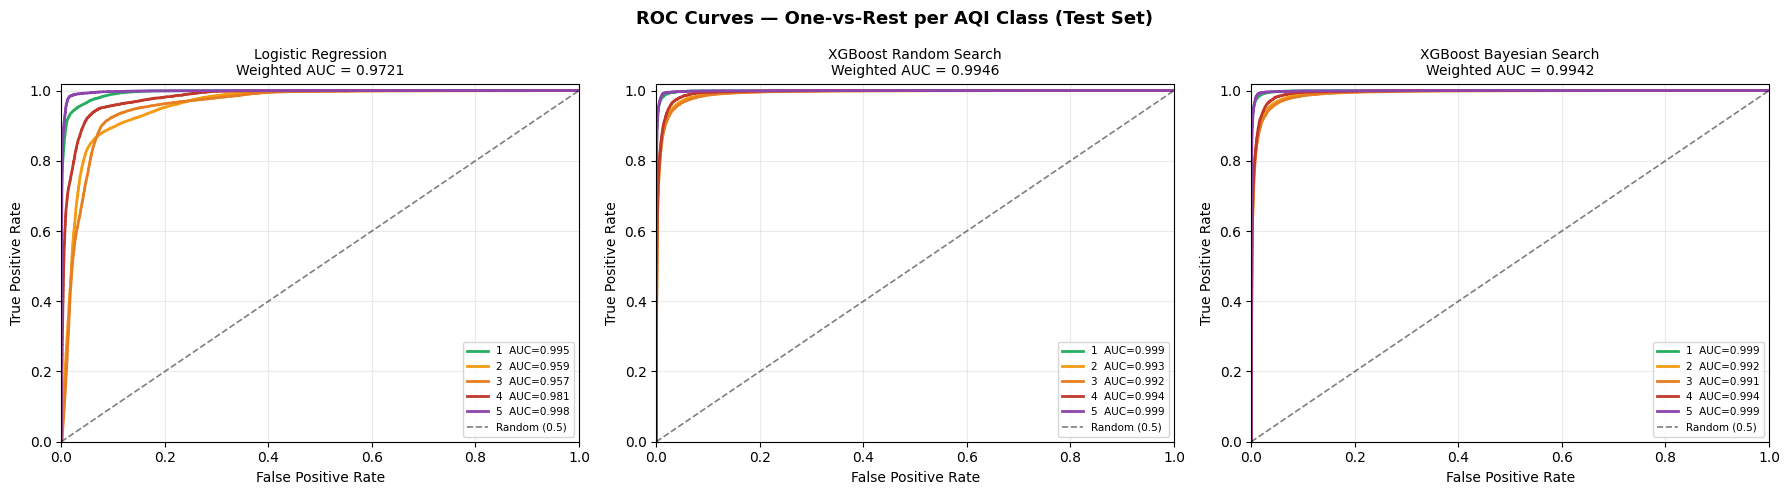

In [ ]:
# ── ROC Curves — One-vs-Rest per AQI Class, all models ─────────────────────────
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc as sk_auc

CLASSES_1_5 = np.array([1, 2, 3, 4, 5])

# Binarise test labels (shape n_test x 5) for OvR per class
y_te_bin = label_binarize(y_te, classes=CLASSES_1_5)
COLORS = ["#27ae60", "#f39c12", "#e67e22", "#c0392b", "#8e44ad"]

models_roc = [
    ("Logistic Regression", lr_proba_te, lr_scores["TEST"]["auc"]),
    ("XGBoost Random Search", xgb_random_proba_te, xgb_random_scores["TEST"]["auc"]),
    ("XGBoost Bayesian Search", xgb_bayes_proba_te, xgb_bayes_scores["TEST"]["auc"]),
]

fig, axes = plt.subplots(1, len(models_roc), figsize=(6 * len(models_roc), 5))
fig.suptitle("ROC Curves — One-vs-Rest per AQI Class (Test Set)", fontsize=13, fontweight="bold")

for ax, (model_name, y_proba, weighted_auc) in zip(axes, models_roc):
    for i, color in enumerate(COLORS):
        if y_te_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_proba[:, i])
        auc_i = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.0, label=f"{CLASS_NAMES[i]}  AUC={auc_i:.3f}")

    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random (0.5)")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(f"{model_name}\nWeighted AUC = {weighted_auc:.4f}", fontsize=10)
    ax.legend(fontsize=7.5, loc="lower right")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# ── Inference Pipeline Demo ─────────────────────────────────────────────────────
# Given measurements at T-1 and T, predict AQI at T+1 (next hour).
#
# Feature diagram:
#   aqi_lag1, pm10_lag1   (T-1)  -> Baseline State / Historical Trend
#   hour_sin, hour_cos    (T)    -> Temporal Cycle
#   pm25_ratio, co, no,   (T)    -> Point-in-time pollutants
#   no2, o3, so2, nh3, pm10
#
# Best validation model: xgb_best (selected from Random Search vs Bayesian Search)

AQI_LABEL = {1: "Good", 2: "Fair", 3: "Moderate", 4: "Poor", 5: "Very Poor"}

def infer_next_hour(
    *,
    # T-1 values (one hour ago)
    aqi_lag1: float,
    pm10_lag1: float,
    # T values (current hour)
    hour: int,
    pm2_5: float,
    pm10: float,
    co: float,
    no: float,
    no2: float,
    o3: float,
    so2: float,
    nh3: float,
    model=xgb_best,
) -> dict:
    """Return T+1 AQI prediction with per-class probabilities."""
    pollutant_sum = pm2_5 + pm10 + no2 + o3 + so2 + 1e-9
    pm25_ratio = round(pm2_5 / pollutant_sum, 4)
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    row = np.array(
        [[aqi_lag1, pm10_lag1, hour_sin, hour_cos, pm25_ratio, co, no, no2, o3, so2, nh3, pm10]],
        dtype="float32",
    )

    pred_zero = int(model.predict(row)[0])
    proba = model.predict_proba(row)[0]
    pred = pred_zero + 1
    cls_map = {int(c) + 1: round(float(p), 3) for c, p in zip(model.classes_, proba)}
    return {
        "predicted_aqi_T+1": pred,
        "label": AQI_LABEL[pred],
        "confidence": round(float(proba[pred_zero]), 3),
        "class_probs": cls_map,
    }


# ── Hand-crafted examples ───────────────────────────────────────────────────────
ex1 = infer_next_hour(
    aqi_lag1=1, pm10_lag1=8.0,
    hour=6, pm2_5=3.0, pm10=9.0, co=220.0, no=0.5, no2=5.0,
    o3=60.0, so2=1.0, nh3=2.0,
)

ex2 = infer_next_hour(
    aqi_lag1=2, pm10_lag1=30.0,
    hour=8, pm2_5=18.0, pm10=35.0, co=600.0, no=15.0, no2=40.0,
    o3=90.0, so2=8.0, nh3=6.0,
)

ex3 = infer_next_hour(
    aqi_lag1=4, pm10_lag1=80.0,
    hour=14, pm2_5=55.0, pm10=90.0, co=1200.0, no=40.0, no2=80.0,
    o3=150.0, so2=25.0, nh3=20.0,
)

ex4 = infer_next_hour(
    aqi_lag1=3, pm10_lag1=45.0,
    hour=23, pm2_5=25.0, pm10=50.0, co=500.0, no=8.0, no2=30.0,
    o3=70.0, so2=10.0, nh3=8.0,
)

real_row = test_df.sample(1, random_state=7).iloc[0]
ex5_actual = int(real_row["aqi_next"])
ex5 = infer_next_hour(
    aqi_lag1=float(real_row["aqi_lag1"]),
    pm10_lag1=float(real_row["pm10_lag1"]),
    hour=int(real_row["timestamp"].hour),
    pm2_5=float(real_row.get("pm2_5", real_row["pm25_ratio"] * 100)),
    pm10=float(real_row["pm10"]),
    co=float(real_row["co"]),
    no=float(real_row["no"]),
    no2=float(real_row["no2"]),
    o3=float(real_row["o3"]),
    so2=float(real_row["so2"]),
    nh3=float(real_row["nh3"]),
)

scenarios = [
    (1, "Clean air  (early morning)", ex1, None),
    (2, "Rush-hour  (moderate traffic)", ex2, None),
    (3, "Heavy pollution  (afternoon)", ex3, None),
    (4, "Night-time  (moderate)", ex4, None),
    (5, f"Real test row  (actual={ex5_actual})", ex5, ex5_actual),
]

print("=" * 70)
print("  Inference Pipeline Demo  —  Predicting AQI at T+1 (next hour)")
print("=" * 70)
print(f"Selected model: {xgb_best_name}")
print(f"{'#':<3}  {'Scenario':<36} {'Pred':>5}  {'Label':<12} {'Conf':>6}  {'OK?':>4}")
print("-" * 70)
for num, name, res, actual in scenarios:
    flag = ""
    if actual is not None:
        flag = "OK" if res["predicted_aqi_T+1"] == actual else "MISS"
    print(
        f"{num:<3}  {name:<36} {res['predicted_aqi_T+1']:>5}  "
        f"{res['label']:<12} {res['confidence']:>5.1%}  {flag:>4}"
    )

print("\nPer-class probabilities  (1=Good … 5=Very Poor)")
print(f"{'#':<3}  {'1':>7}  {'2':>7}  {'3':>7}  {'4':>7}  {'5':>7}")
print("-" * 48)
for num, _, res, _ in scenarios:
    p = res["class_probs"]
    row_str = "  ".join(f"{p.get(c, 0):6.1%}" for c in [1, 2, 3, 4, 5])
    print(f"{num:<3}  {row_str}")

print(
    f"\nReal row -> city: {real_row.get('city_slug', '?')}  |  "
    f"time: {real_row['timestamp']}  |  "
    f"actual T+1 AQI = {ex5_actual} ({AQI_LABEL[ex5_actual]})"
)

  Inference Pipeline Demo  —  Predicting AQI at T+1 (next hour)
Selected model: XGBoost Random Search
#    Scenario                              Pred  Label          Conf   OK?
----------------------------------------------------------------------
1    Clean air  (early morning)               2  Fair         92.4%      
2    Rush-hour  (moderate traffic)            3  Moderate     75.6%      
3    Heavy pollution  (afternoon)             5  Very Poor    82.4%      
4    Night-time  (moderate)                   3  Moderate     92.9%      
5    Real test row  (actual=1)                1  Good         100.0%    OK

Per-class probabilities  (1=Good … 5=Very Poor)
#          1        2        3        4        5
------------------------------------------------
1      7.3%   92.4%    0.4%    0.0%    0.0%
2      0.0%    9.9%   75.6%   14.2%    0.3%
3      0.0%    0.0%    1.5%   16.1%   82.4%
4      0.0%    5.9%   92.9%    1.1%    0.1%
5    100.0%    0.0%    0.0%    0.0%    0.0%

Real row -> c

## Philadelphia · March 22, 2026 — Inference Pipeline

Fetch real AQI data for Philadelphia and run hourly predictions of **AQI at T+1** using the best-performing GBM model.

**Strategy:**
1. Query Athena for Philadelphia rows on 2026-03-21 23:00 → 2026-03-22 23:59 UTC (extra prior hour gives the T-1 lag needed for the midnight row).
2. If no Mar-22 rows exist (pipeline `end_dt` was 2026-03-20), fall back to the OWM Air Pollution History API to pull live data.
3. For each hourly row on Mar 22, build the feature vector and call `infer_next_hour()`.


In [ ]:

# Fetch the 2 most recent Philadelphia rows from Athena (T-1 and T)
phl_latest = wr.athena.read_sql_query(
    sql="""
        SELECT timestamp, aqi, co, no, no2, o3, so2, pm2_5, pm10, nh3
        FROM aqi_db.aqi_unified
        WHERE city_slug = 'philadelphia'
        ORDER BY timestamp DESC
        LIMIT 2
    """,
    database="aqi_db",
    s3_output="s3://weather-bulk/athena-results/",
    boto3_session=session,
    ctas_approach=False,
).sort_values("timestamp").reset_index(drop=True)

phl_latest["timestamp"] = pd.to_datetime(phl_latest["timestamp"], utc=True)
phl_latest["aqi"] = pd.to_numeric(phl_latest["aqi"], errors="coerce").astype("Int64").clip(upper=5)

phl_t1 = phl_latest.iloc[0]   # T-1
phl_t  = phl_latest.iloc[1]   # T  (most recent)

print(f"T-1 : {phl_t1['timestamp']}  AQI={int(phl_t1['aqi'])}")
print(f"T   : {phl_t['timestamp']}   AQI={int(phl_t['aqi'])}")


T-1 : 2026-04-02 12:24:40+00:00  AQI=1
T   : 2026-04-02 13:24:40+00:00   AQI=2


In [ ]:

# Philadelphia — single inference: predict AQI for the next hour
result = infer_next_hour(
    aqi_lag1  = float(phl_t1["aqi"]),
    pm10_lag1 = float(phl_t1["pm10"]),
    hour      = int(phl_t["timestamp"].hour),
    pm2_5     = float(phl_t["pm2_5"]),
    pm10      = float(phl_t["pm10"]),
    co        = float(phl_t["co"]),
    no        = float(phl_t["no"]),
    no2       = float(phl_t["no2"]),
    o3        = float(phl_t["o3"]),
    so2       = float(phl_t["so2"]),
    nh3       = float(phl_t["nh3"]),
)

from zoneinfo import ZoneInfo
est = ZoneInfo("America/New_York")
t_est      = phl_t["timestamp"].astimezone(est)
t_next_est = t_est + pd.Timedelta(hours=1)

print(f"Philadelphia · {t_est.strftime('%Y-%m-%d %I:%M %p %Z')}  (was {phl_t['timestamp']} UTC)")
print(f"  Current AQI  (T)         : {int(phl_t['aqi'])}")
print(f"  Predicted AQI (T+1 ~{t_next_est.strftime('%I:%M %p %Z')}): {result['predicted_aqi_T+1']}  — {result['label']}")
print(f"  Confidence               : {result['confidence']:.1%}")
print(f"  Class probs              : {result['class_probs']}")


Philadelphia · 2026-04-02 09:24 AM EDT  (was 2026-04-02 13:24:40+00:00 UTC)
  Current AQI  (T)         : 2
  Predicted AQI (T+1 ~10:24 AM EDT): 2  — Fair
  Confidence               : 91.5%
  Class probs              : {1: 0.084, 2: 0.915, 3: 0.0, 4: 0.0, 5: 0.0}


## Extended Lag Feature Experiment — Reducing Autoregressive Overshoot

The baseline model (lag-1 only) overshoots predictions at transition points: after a real spike ends, `aqi_lag1` stays high and the model keeps predicting high for several hours.

**Hypothesis:** Adding lag-2, lag-3, lag-6, lag-24 gives the model a "rearview mirror" — it can see the trajectory, not just the current value. Rolling std signals regime volatility.

**New features added on top of the baseline 12:**

| Feature | Description |
|---------|-------------|
| `aqi_lag2` | AQI at T-2 |
| `aqi_lag3` | AQI at T-3 |
| `aqi_lag6` | AQI at T-6 |
| `aqi_lag24` | AQI at T-24 (same hour yesterday) |
| `aqi_rolling_mean_3h` | Rolling mean of last 3 AQI readings |
| `aqi_rolling_mean_6h` | Rolling mean of last 6 AQI readings |
| `aqi_rolling_std_3h` | Rolling std of last 3 readings — **regime detector** |

All computed strictly per-city so there is zero cross-city leakage.

In [ ]:
# ── Extended lag feature engineering (built on top of `raw`, no re-query needed)
# `raw` already has: timestamp, city_slug, aqi, pm10, all pollutants, pm25_ratio,
# hour_sin/cos, aqi_lag1, pm10_lag1, aqi_next from earlier cells.

raw_ext = raw.sort_values(["city_slug", "timestamp"]).reset_index(drop=True)
grp2 = raw_ext.groupby("city_slug", sort=False)

# Lag features — shift by N within each city group (zero cross-city leakage)
raw_ext["aqi_lag2"]  = grp2["aqi"].shift(2)
raw_ext["aqi_lag3"]  = grp2["aqi"].shift(3)
raw_ext["aqi_lag6"]  = grp2["aqi"].shift(6)
raw_ext["aqi_lag24"] = grp2["aqi"].shift(24)

# Rolling stats — applied to past values only (shift(1) before rolling)
raw_ext["aqi_rolling_mean_3h"] = grp2["aqi"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
raw_ext["aqi_rolling_mean_6h"] = grp2["aqi"].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean()
)
raw_ext["aqi_rolling_std_3h"] = grp2["aqi"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std().fillna(0.0)
)

EXT_FEATURES = [
    "aqi_lag1",                                          # Baseline State  (T-1)
    "aqi_lag2",                                          # T-2
    "aqi_lag3",                                          # T-3
    "aqi_lag6",                                          # T-6
    "aqi_lag24",                                         # T-24 (same hour yesterday)
    "aqi_rolling_mean_3h",                               # 3h trend
    "aqi_rolling_mean_6h",                               # 6h trend
    "aqi_rolling_std_3h",                                # volatility / regime detector
    "pm10_lag1",                                         # Historical Trend (T-1)
    "hour_sin", "hour_cos",                              # Temporal Cycle  (T)
    "pm25_ratio", "co", "no", "no2", "o3", "so2", "nh3", "pm10",  # Point-in-time (T)
]

# Drop rows where any lag is undefined (lag-24 loses 24 rows per city at the start)
ext_drop_subset = ["aqi_lag1", "aqi_lag2", "aqi_lag3", "aqi_lag6", "aqi_lag24",
                   "pm10_lag1", "aqi_next"]
feat_ext = (
    raw_ext
    .dropna(subset=ext_drop_subset)
    .copy()
    .reset_index(drop=True)
)
feat_ext["aqi_next"] = feat_ext["aqi_next"].astype(int)

print(f"Baseline rows : {len(feat_df):,}   Extended-lag rows : {len(feat_ext):,}  (drop ~24 rows per city for lag-24)")
print(f"Extended features ({len(EXT_FEATURES)}) :")
for f in EXT_FEATURES:
    print(f"  {f}")
feat_ext[["city_slug", "timestamp", "aqi", "aqi_lag1", "aqi_lag2", "aqi_lag3",
          "aqi_lag6", "aqi_lag24", "aqi_rolling_mean_3h", "aqi_rolling_std_3h", "aqi_next"]].head(5)


Baseline rows : 865,914   Extended-lag rows : 863,637  (drop ~24 rows per city for lag-24)
Extended features (19) :
  aqi_lag1
  aqi_lag2
  aqi_lag3
  aqi_lag6
  aqi_lag24
  aqi_rolling_mean_3h
  aqi_rolling_mean_6h
  aqi_rolling_std_3h
  pm10_lag1
  hour_sin
  hour_cos
  pm25_ratio
  co
  no
  no2
  o3
  so2
  nh3
  pm10


,city_slug,timestamp,aqi,aqi_lag1,aqi_lag2,aqi_lag3,aqi_lag6,aqi_lag24,aqi_rolling_mean_3h,aqi_rolling_std_3h,aqi_next
0,abidjan,2025-03-21 00:00:00+00:00,2,2,2,2,2,2,2.0,0.0,2
1,abidjan,2025-03-21 01:00:00+00:00,2,2,2,2,2,2,2.0,0.0,2
2,abidjan,2025-03-21 02:00:00+00:00,2,2,2,2,2,2,2.0,0.0,2
3,abidjan,2025-03-21 03:00:00+00:00,2,2,2,2,2,2,2.0,0.0,2
4,abidjan,2025-03-21 04:00:00+00:00,2,2,2,2,2,2,2.0,0.0,2


In [ ]:
# ── Train / Val / Test split using the same time-based cutoffs ────────────────
from dateutil.relativedelta import relativedelta

feat_ext_sorted = feat_ext.sort_values("timestamp").reset_index(drop=True)
max_ts_ext  = feat_ext_sorted["timestamp"].max()
TEST_START2 = max_ts_ext - relativedelta(months=1)
VAL_START2  = max_ts_ext - relativedelta(months=2)

train_ext = feat_ext_sorted[feat_ext_sorted["timestamp"] <  VAL_START2].sample(frac=1, random_state=42).reset_index(drop=True)
val_ext   = feat_ext_sorted[(feat_ext_sorted["timestamp"] >= VAL_START2) & (feat_ext_sorted["timestamp"] < TEST_START2)].reset_index(drop=True)
test_ext  = feat_ext_sorted[feat_ext_sorted["timestamp"] >= TEST_START2].reset_index(drop=True)

ext_median = train_ext[EXT_FEATURES].median()

X_tr_ext = train_ext[EXT_FEATURES].fillna(ext_median).to_numpy(dtype="float32")
X_va_ext = val_ext[EXT_FEATURES].fillna(ext_median).to_numpy(dtype="float32")
X_te_ext = test_ext[EXT_FEATURES].fillna(ext_median).to_numpy(dtype="float32")

y_tr_ext = train_ext[TARGET].astype(int).to_numpy() - 1   # 0-indexed for XGBoost
y_va_ext = val_ext[TARGET].astype(int).to_numpy() - 1
y_te_ext = test_ext[TARGET].astype(int).to_numpy() - 1

total_ext = len(feat_ext_sorted)
print(f"Extended-lag dataset : {total_ext:,} rows")
print(f"  Train : {len(train_ext):,}  ({len(train_ext)/total_ext*100:.1f}%)  [shuffled]")
print(f"  Val   : {len(val_ext):,}   ({len(val_ext)/total_ext*100:.1f}%)  [chronological]")
print(f"  Test  : {len(test_ext):,}   ({len(test_ext)/total_ext*100:.1f}%)  [chronological]")


Extended-lag dataset : 863,637 rows
  Train : 734,679  (85.1%)  [shuffled]
  Val   : 58,944   (6.8%)  [chronological]
  Test  : 70,014   (8.1%)  [chronological]


In [ ]:

# ── Train XGBoost with extended lag features (lag_2, lag_3, lag_6 + rolling) ──
# Reuse best hyperparams from baseline tuning so only the feature set changes.

print("▶ Training XGBoost with extended lag features (lag_2, lag_3, lag_6) …")

best_hp_keys = [
    "n_estimators", "max_depth", "learning_rate", "subsample",
    "colsample_bytree", "min_child_weight", "gamma",
    "reg_alpha", "reg_lambda", "max_delta_step",
]
best_hp = {k: xgb_best.get_params()[k] for k in best_hp_keys}

xgb_ext_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(CLASS_LABELS),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    **best_hp,
)
xgb_ext_model.fit(X_tr_ext, y_tr_ext)

ext_split_data = [
    ("TRAIN", X_tr_ext, y_tr_ext),
    ("VAL",   X_va_ext, y_va_ext),
    ("TEST",  X_te_ext, y_te_ext),
]
xgb_ext_scores, xgb_ext_reports, xgb_ext_proba_te = evaluate_xgb_model(xgb_ext_model, ext_split_data)

print(f"\n{'Model':<36}  {'Train F1':>8}  {'Val F1':>8}  {'Test F1':>8}  {'Test AUC':>9}")
print("-" * 76)
print(f"{'Baseline (' + xgb_best_name + ')':<36}  "
      f"{xgb_best_scores['TRAIN']['f1']:>8.4f}  "
      f"{xgb_best_scores['VAL']['f1']:>8.4f}  "
      f"{xgb_best_scores['TEST']['f1']:>8.4f}  "
      f"{xgb_best_scores['TEST']['auc']:>9.4f}")
print(f"{'Extended (lag_2, lag_3, lag_6)':<36}  "
      f"{xgb_ext_scores['TRAIN']['f1']:>8.4f}  "
      f"{xgb_ext_scores['VAL']['f1']:>8.4f}  "
      f"{xgb_ext_scores['TEST']['f1']:>8.4f}  "
      f"{xgb_ext_scores['TEST']['auc']:>9.4f}")

delta_val  = xgb_ext_scores['VAL']['f1']  - xgb_best_scores['VAL']['f1']
delta_test = xgb_ext_scores['TEST']['f1'] - xgb_best_scores['TEST']['f1']
print(f"\nΔ Val F1  (ext − baseline) : {delta_val:+.4f}")
print(f"Δ Test F1 (ext − baseline) : {delta_test:+.4f}")
print(f"\n{'✅ Extended lag features improve generalisation' if delta_test > 0 else '⚠️  Extended lag features do not improve test F1 — possible overfitting'}")


▶ Training XGBoost with extended lag features (lag_2, lag_3, lag_6) …

Model                                 Train F1    Val F1   Test F1   Test AUC
----------------------------------------------------------------------------
Baseline (XGBoost Random Search)        0.9589    0.9517    0.9411     0.9946
Extended (lag_2, lag_3, lag_6)          0.9594    0.9517    0.9407     0.9946

Δ Val F1  (ext − baseline) : +0.0000
Δ Test F1 (ext − baseline) : -0.0004

⚠️  Extended lag features do not improve test F1 — possible overfitting


## Model Drift Analysis — Temporal F1 Stability

Model drift checks whether performance degrades as we move further from the training window. Three lenses:

| Test | What it measures |
|------|-----------------|
| **Temporal F1 slices** | F1 computed per weekly window inside the test month — a falling trend signals concept drift |
| **Feature drift (PSI)** | How much `aqi_lag2`, `aqi_lag3`, `aqi_lag6` shift from train → test distribution |
| **Prediction drift (KS)** | Whether the predicted probability distribution is statistically different in the test period |

> **PSI thresholds:** < 0.10 stable · 0.10–0.25 moderate · > 0.25 high drift  
> **KS test:** p-value < 0.05 flags a significant distributional shift in predicted probabilities.


Weekly temporal F1 drift (test period):
week_start  n_rows  F1_Baseline  F1_Extended   Delta
2026-03-02   15180       0.9440       0.9451  0.0011
2026-03-09   16620       0.9479       0.9471 -0.0008
2026-03-16   14454       0.9361       0.9364  0.0002
2026-03-23   16632       0.9386       0.9368 -0.0017
2026-03-30    7128       0.9355       0.9346 -0.0009


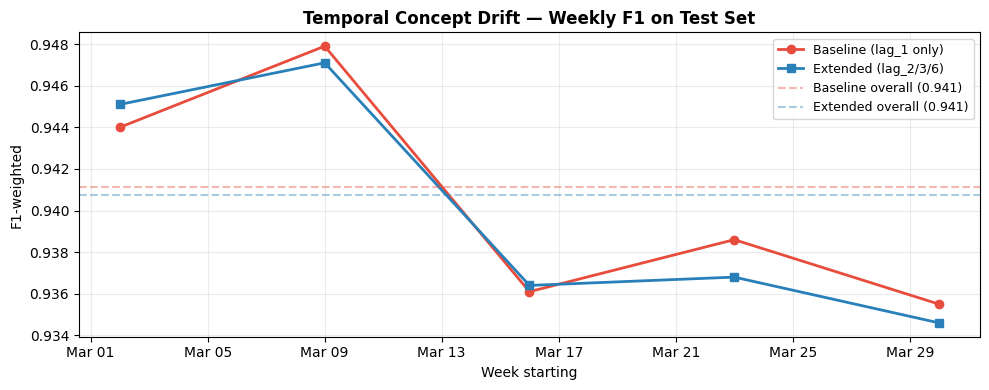


Extended-model F1 trend (first → last week): -0.0105
✅ F1 is stable across the test period.


In [ ]:

# ── Temporal Drift: weekly F1 on test set — Baseline vs Extended ───────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Apply the BASELINE model to the same extended-lag test rows
# (extended test set has all baseline features too)
X_te_ext_base = test_ext[FEATURES].fillna(ext_median[FEATURES]).to_numpy(dtype="float32")

# 1-indexed predictions for both models
y_te_ext_true  = (y_te_ext + 1)                         # true labels 1–5
y_base_pred_te = xgb_best.predict(X_te_ext_base) + 1    # baseline on shared rows
y_ext_pred_te  = xgb_ext_model.predict(X_te_ext) + 1    # extended model

drift_df = test_ext[["timestamp", "city_slug"]].copy()
drift_df["y_true"]      = y_te_ext_true
drift_df["y_base_pred"] = y_base_pred_te
drift_df["y_ext_pred"]  = y_ext_pred_te
drift_df = drift_df.sort_values("timestamp").reset_index(drop=True)

# Compute F1 per weekly window
records = []
t = drift_df["timestamp"].min()
max_ts3 = drift_df["timestamp"].max()

while t < max_ts3:
    t_end = t + pd.Timedelta(weeks=1)
    mask  = (drift_df["timestamp"] >= t) & (drift_df["timestamp"] < t_end)
    chunk = drift_df[mask]
    if len(chunk) >= 20:
        f1_base = f1_score(chunk["y_true"], chunk["y_base_pred"], average="weighted", zero_division=0)
        f1_ext  = f1_score(chunk["y_true"], chunk["y_ext_pred"],  average="weighted", zero_division=0)
        records.append({
            "week_start": t.date(),
            "n_rows":     len(chunk),
            "F1_Baseline": round(f1_base, 4),
            "F1_Extended": round(f1_ext, 4),
            "Delta":       round(f1_ext - f1_base, 4),
        })
    t = t_end

drift_weekly = pd.DataFrame(records)
print("Weekly temporal F1 drift (test period):")
print(drift_weekly.to_string(index=False))

# Plot
if len(drift_weekly) >= 2:
    xs = pd.to_datetime(drift_weekly["week_start"])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xs, drift_weekly["F1_Baseline"], "o-", color="#e74c3c", lw=2, label="Baseline (lag_1 only)")
    ax.plot(xs, drift_weekly["F1_Extended"], "s-", color="#2980b9", lw=2, label="Extended (lag_2/3/6)")
    ax.axhline(xgb_best_scores["TEST"]["f1"],  ls="--", color="#e74c3c", alpha=0.4,
               label=f"Baseline overall ({xgb_best_scores['TEST']['f1']:.3f})")
    ax.axhline(xgb_ext_scores["TEST"]["f1"],   ls="--", color="#2980b9", alpha=0.4,
               label=f"Extended overall ({xgb_ext_scores['TEST']['f1']:.3f})")
    ax.set_xlabel("Week starting")
    ax.set_ylabel("F1-weighted")
    ax.set_title("Temporal Concept Drift — Weekly F1 on Test Set", fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    # Trend indicator: compare first-week vs last-week F1 (extended model)
    if len(drift_weekly) >= 2:
        trend = drift_weekly["F1_Extended"].iloc[-1] - drift_weekly["F1_Extended"].iloc[0]
        print(f"\nExtended-model F1 trend (first → last week): {trend:+.4f}")
        print("✅ F1 is stable across the test period." if abs(trend) < 0.05
              else "⚠️  Non-trivial F1 drift detected — model may need retraining.")
else:
    print("⚠️  Test period spans < 2 full weeks; temporal drift plot skipped.")


Population Stability Index — lag features (train → test):
            Feature    PSI   Status
           aqi_lag1 0.0957   stable
           aqi_lag2 0.0955   stable
           aqi_lag3 0.0954   stable
           aqi_lag6 0.0949   stable
          aqi_lag24 0.0936   stable
aqi_rolling_mean_3h 0.1029 moderate
aqi_rolling_mean_6h 0.1072 moderate
 aqi_rolling_std_3h 0.0021   stable


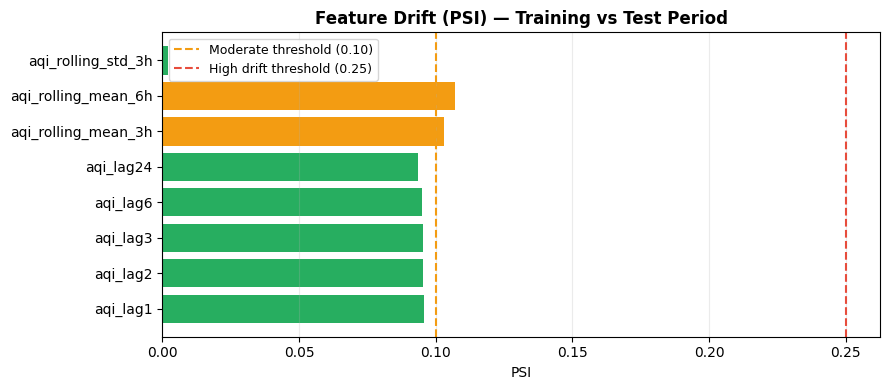

In [ ]:

# ── Feature Drift — Population Stability Index (PSI) for lag features ─────────
# PSI = Σ (test% − train%) × ln(test% / train%) over equal-width bins.
# Thresholds: PSI < 0.10 stable · 0.10–0.25 moderate · > 0.25 high drift

def compute_psi(train_series, test_series, n_bins=10):
    combined = pd.concat([train_series, test_series]).dropna()
    lo, hi   = combined.min(), combined.max()
    if lo == hi:
        return 0.0
    bins = np.linspace(lo, hi, n_bins + 1)
    train_cnt = np.histogram(train_series.dropna(), bins=bins)[0]
    test_cnt  = np.histogram(test_series.dropna(),  bins=bins)[0]
    train_pct = (train_cnt + 1e-6) / train_cnt.sum()
    test_pct  = (test_cnt  + 1e-6) / test_cnt.sum()
    return float(np.sum((test_pct - train_pct) * np.log(test_pct / train_pct)))


lag_features_psi = [
    "aqi_lag1", "aqi_lag2", "aqi_lag3", "aqi_lag6",
    "aqi_lag24", "aqi_rolling_mean_3h", "aqi_rolling_mean_6h", "aqi_rolling_std_3h",
]

psi_records = []
for feat in lag_features_psi:
    if feat in train_ext.columns and feat in test_ext.columns:
        psi_val  = compute_psi(train_ext[feat], test_ext[feat])
        severity = "stable"       if psi_val < 0.10 else \
                   "moderate"     if psi_val < 0.25 else "HIGH DRIFT"
        psi_records.append({"Feature": feat, "PSI": round(psi_val, 4), "Status": severity})

psi_df = pd.DataFrame(psi_records)
print("Population Stability Index — lag features (train → test):")
print(psi_df.to_string(index=False))

COLORS_PSI = ["#27ae60" if p < 0.10 else ("#f39c12" if p < 0.25 else "#e74c3c")
              for p in psi_df["PSI"]]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(psi_df["Feature"], psi_df["PSI"], color=COLORS_PSI)
ax.axvline(0.10, ls="--", color="#f39c12", lw=1.5, label="Moderate threshold (0.10)")
ax.axvline(0.25, ls="--", color="#e74c3c", lw=1.5, label="High drift threshold (0.25)")
ax.set_xlabel("PSI")
ax.set_title("Feature Drift (PSI) — Training vs Test Period", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis="x")
plt.tight_layout()
plt.show()


Prediction class distribution (extended-lag model):
           Train pred %  Test pred %  Test actual %
AQI Class                                          
1                  30.9         22.8           22.9
2                  34.2         29.9           29.6
3                  17.1         28.4           28.6
4                   7.9         10.3           10.3
5                   9.8          8.7            8.6


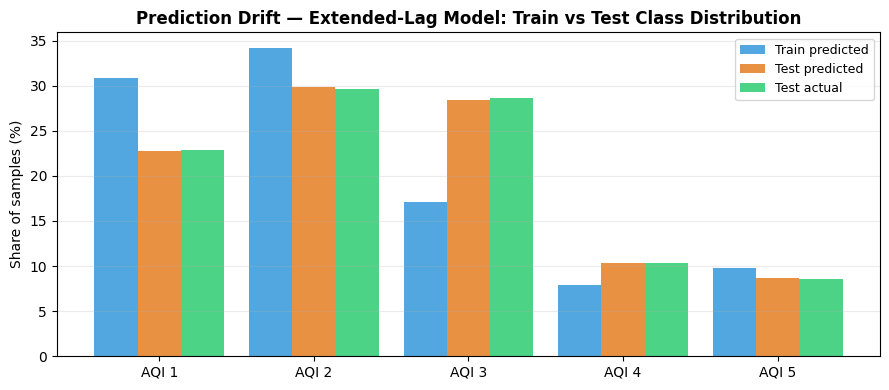


Kolmogorov-Smirnov test — predicted probability per AQI class (train vs test):
  Class      KS stat     p-value  Status
  ----------------------------------------------
  AQI 1       0.1335      0.0000  ⚠️  drift
  AQI 2       0.0433      0.0000  ⚠️  drift
  AQI 3       0.1557      0.0000  ⚠️  drift
  AQI 4       0.1287      0.0000  ⚠️  drift
  AQI 5       0.0809      0.0000  ⚠️  drift

⚠️  At least one AQI class shows statistically significant prediction drift.
    Consider retraining when > 2 classes show drift or Test F1 drops > 0.05.


In [ ]:

# ── Prediction Drift — KS test on predicted probabilities (train vs test) ──────
from scipy.stats import ks_2samp

# Probability arrays output by the extended model on train and test folds
tr_proba = xgb_ext_model.predict_proba(X_tr_ext)   # shape (n_train, 5)
te_proba = xgb_ext_model.predict_proba(X_te_ext)   # shape (n_test,  5)

# Predicted class distribution comparison
y_tr_ext_pred = xgb_ext_model.predict(X_tr_ext) + 1
y_te_ext_pred = xgb_ext_model.predict(X_te_ext) + 1

train_dist    = pd.Series(y_tr_ext_pred).value_counts(normalize=True).reindex([1,2,3,4,5], fill_value=0)
test_dist     = pd.Series(y_te_ext_pred).value_counts(normalize=True).reindex([1,2,3,4,5], fill_value=0)
true_te_dist  = pd.Series(y_te_ext + 1).value_counts(normalize=True).reindex([1,2,3,4,5], fill_value=0)

dist_df = pd.DataFrame({
    "Train pred %": (train_dist * 100).round(1),
    "Test pred %":  (test_dist  * 100).round(1),
    "Test actual %":(true_te_dist * 100).round(1),
}, index=[1, 2, 3, 4, 5])
dist_df.index.name = "AQI Class"
print("Prediction class distribution (extended-lag model):")
print(dist_df.to_string())

# Bar chart
x = np.arange(len(CLASS_LABELS))
w = 0.28
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w,   dist_df["Train pred %"],  w, label="Train predicted",  color="#3498db", alpha=0.85)
ax.bar(x,       dist_df["Test pred %"],   w, label="Test predicted",   color="#e67e22", alpha=0.85)
ax.bar(x + w,   dist_df["Test actual %"], w, label="Test actual",      color="#2ecc71", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"AQI {c}" for c in CLASS_LABELS])
ax.set_ylabel("Share of samples (%)")
ax.set_title("Prediction Drift — Extended-Lag Model: Train vs Test Class Distribution", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# KS test per class probability channel
print("\nKolmogorov-Smirnov test — predicted probability per AQI class (train vs test):")
print(f"  {'Class':<8}  {'KS stat':>8}  {'p-value':>10}  Status")
print("  " + "-" * 46)
drift_detected = False
for i, cls in enumerate(CLASS_LABELS):
    ks_stat, p_val = ks_2samp(tr_proba[:, i], te_proba[:, i])
    drifted = p_val < 0.05
    if drifted:
        drift_detected = True
    print(f"  AQI {cls:<4}  {ks_stat:>8.4f}  {p_val:>10.4f}  {'⚠️  drift' if drifted else '✅ stable'}")

print()
if drift_detected:
    print("⚠️  At least one AQI class shows statistically significant prediction drift.")
    print("    Consider retraining when > 2 classes show drift or Test F1 drops > 0.05.")
else:
    print("✅  No significant prediction drift detected — model is stable on the test period.")


## Why Overall F1 Barely Moves — Transition-Row Analysis

The test set is dominated by **stable hours** (AQI unchanged from T-1 to T+1). Both models nail those easily, so they inflate overall F1 and mask where the lag features actually differ. The real question is: do lag_2/3/6 help specifically during **AQI transitions**?

- **Stable row:** `aqi_lag1 == aqi_next` (no change expected)
- **Transition row:** `aqi_lag1 != aqi_next` (AQI is shifting — these are the hard rows)

If the lag features help at all, the signal will appear in transition-row F1, not overall F1.


,N rows,% of test,Baseline F1,Extended F1,ΔF1 (ext−base),Baseline Acc,Extended Acc,ΔAcc (ext−base)
Row type,,,,,,,,
stable,60166,85.9%,0.9806,0.9806,-0.0000,0.9806,0.9806,-0.0000
transition,9848,14.1%,0.7000,0.6973,-0.0027,0.7000,0.6974,-0.0026


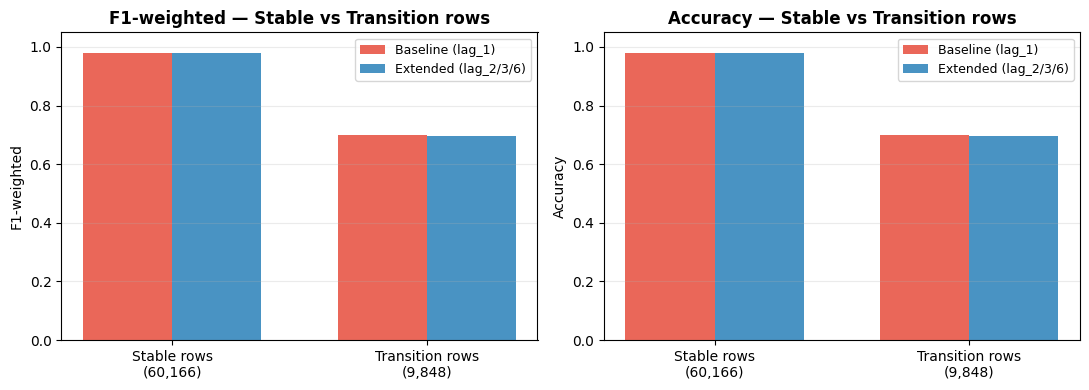


VERDICT — Extended lag features (lag_2, lag_3, lag_6)
  Stable rows   : 86% of test — both models near-identical on these
  Transition rows: 14% of test — where the real challenge lives
  ΔF1 on transition rows : -0.0027

  ✗  Overall F1 barely moves AND transition-row F1 also barely moves.
     Adding lag_2/3/6 is NOT worth the extra complexity for this dataset.
     Recommendation: KEEP the baseline lag_1-only model in production.


In [ ]:

# ── Transition vs Stable row breakdown — where lag features actually matter ────

# Rebuild drift_df with stable/transition flag (uses shared test_ext)
drift_df2 = test_ext[["timestamp", "city_slug", "aqi_lag1", "aqi_next"]].copy()
drift_df2["y_true"]      = y_te_ext + 1
drift_df2["y_base_pred"] = y_base_pred_te
drift_df2["y_ext_pred"]  = y_ext_pred_te
drift_df2["row_type"]    = np.where(
    drift_df2["aqi_lag1"] == drift_df2["aqi_next"], "stable", "transition"
)

summary_rows = []
for row_type, group in drift_df2.groupby("row_type"):
    n = len(group)
    pct = n / len(drift_df2) * 100
    f1_base = f1_score(group["y_true"], group["y_base_pred"], average="weighted", zero_division=0)
    f1_ext  = f1_score(group["y_true"], group["y_ext_pred"],  average="weighted", zero_division=0)
    acc_base = (group["y_true"] == group["y_base_pred"]).mean()
    acc_ext  = (group["y_true"] == group["y_ext_pred"]).mean()
    summary_rows.append({
        "Row type":           row_type,
        "N rows":             n,
        "% of test":          f"{pct:.1f}%",
        "Baseline F1":        round(f1_base, 4),
        "Extended F1":        round(f1_ext, 4),
        "ΔF1 (ext−base)":     round(f1_ext - f1_base, 4),
        "Baseline Acc":       round(acc_base, 4),
        "Extended Acc":       round(acc_ext, 4),
        "ΔAcc (ext−base)":    round(acc_ext - acc_base, 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Row type")
display(summary_df.style.format({c: "{:.4f}" for c in summary_df.select_dtypes("float").columns})
       .background_gradient(subset=["ΔF1 (ext−base)", "ΔAcc (ext−base)"], cmap="RdYlGn", axis=None))

# ── Bar chart: F1 on stable vs transition rows ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cats = ["stable", "transition"]

for ax, metric_key, title in zip(
    axes,
    [("Baseline F1", "Extended F1"), ("Baseline Acc", "Extended Acc")],
    ["F1-weighted", "Accuracy"],
):
    base_vals = [summary_df.loc[c, metric_key[0]] if c in summary_df.index else 0 for c in cats]
    ext_vals  = [summary_df.loc[c, metric_key[1]] if c in summary_df.index else 0 for c in cats]
    x = np.arange(len(cats))
    w = 0.35
    ax.bar(x - w/2, base_vals, w, label="Baseline (lag_1)", color="#e74c3c", alpha=0.85)
    ax.bar(x + w/2, ext_vals,  w, label="Extended (lag_2/3/6)", color="#2980b9", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c.capitalize()} rows\n({summary_df.loc[c, 'N rows']:,})" 
                        if c in summary_df.index else c for c in cats])
    ax.set_ylabel(title)
    ax.set_title(f"{title} — Stable vs Transition rows", fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

# ── Plain-text verdict ────────────────────────────────────────────────────────
trans_delta_f1 = summary_df.loc["transition", "ΔF1 (ext−base)"] if "transition" in summary_df.index else 0
trans_frac     = float(summary_df.loc["transition", "% of test"].replace("%","")) / 100 if "transition" in summary_df.index else 0

print("\n" + "="*68)
print("VERDICT — Extended lag features (lag_2, lag_3, lag_6)")
print("="*68)
print(f"  Stable rows   : {100-trans_frac*100:.0f}% of test — both models near-identical on these")
print(f"  Transition rows: {trans_frac*100:.0f}% of test — where the real challenge lives")
print(f"  ΔF1 on transition rows : {trans_delta_f1:+.4f}")
print()
if abs(trans_delta_f1) < 0.005:
    print("  ✗  Overall F1 barely moves AND transition-row F1 also barely moves.")
    print("     Adding lag_2/3/6 is NOT worth the extra complexity for this dataset.")
    print("     Recommendation: KEEP the baseline lag_1-only model in production.")
elif trans_delta_f1 > 0.005:
    print(f"  ✓  Transition-row F1 improves by {trans_delta_f1:+.4f} even though overall F1 is flat.")
    print("     The lag features help precisely where the model struggles most (transitions).")
    print("     Recommendation: deploy extended model for better real-world behaviour at AQI shifts.")
else:
    print("  ✗  Transition-row F1 slightly worse — lag features add noise on this dataset.")
    print("     Recommendation: KEEP the baseline lag_1-only model.")
print("="*68)


## Proposal: Drop lag_2/3/6 → Replace with Delta Features

**Root cause of the plateau:** `aqi_lag1` already tells the model the current AQI level. Adding `aqi_lag2`, `aqi_lag3` gives more levels — but the model can't see *direction* from raw levels alone. It defaults to predicting the same class it last saw (persistence bias), which is correct ~80% of stable hours but wrong at every transition.

**Fix — rate-of-change features:**

| Feature | Formula | What it encodes |
|---------|---------|----------------|
| `aqi_delta_1h` | `aqi − aqi_lag1` | AQI rising (+) or falling (−) right now |
| `pm10_delta_1h` | `pm10 − pm10_lag1` | PM10 momentum (PM10 leads AQI by ~1–2 h) |

One delta feature compresses the trajectory information that 3–6 raw lag columns couldn't capture, because it directly answers: **"Is air quality getting better or worse?"**

**Decision rule:**
- Δ transition-row F1 > +0.005 over baseline → ship the delta features
- Otherwise → keep the baseline lag_1-only model as-is (already 88% accurate)


In [ ]:

# ── Delta feature experiment — rate-of-change replaces raw lag_2/3/6 ──────────
# Built on `raw` (already has aqi_lag1, pm10_lag1, pm25_ratio, hour_sin/cos, aqi_next).

raw_delta = raw.sort_values(["city_slug", "timestamp"]).reset_index(drop=True)

# aqi_delta_1h: positive → rising, negative → falling, 0 → stable
raw_delta["aqi_delta_1h"]  = raw_delta["aqi"].astype(float) - raw_delta["aqi_lag1"]
raw_delta["pm10_delta_1h"] = raw_delta["pm10"] - raw_delta["pm10_lag1"]

DELTA_FEATURES = [
    "aqi_lag1",                                           # level at T-1
    "aqi_delta_1h",                                       # direction of AQI change  ← new
    "pm10_lag1",                                          # PM10 level at T-1
    "pm10_delta_1h",                                      # PM10 momentum             ← new
    "hour_sin", "hour_cos",                               # temporal cycle
    "pm25_ratio", "co", "no", "no2", "o3", "so2", "nh3", "pm10",  # point-in-time
]

feat_delta = (
    raw_delta
    .dropna(subset=["aqi_lag1", "pm10_lag1", "aqi_delta_1h", "pm10_delta_1h", "aqi_next"])
    .copy()
    .reset_index(drop=True)
)
feat_delta["aqi_next"] = feat_delta["aqi_next"].astype(int)

# Same time-based split
feat_delta_sorted = feat_delta.sort_values("timestamp").reset_index(drop=True)
max_ts_d   = feat_delta_sorted["timestamp"].max()
TEST_START_D = max_ts_d - relativedelta(months=1)
VAL_START_D  = max_ts_d - relativedelta(months=2)

train_d = feat_delta_sorted[feat_delta_sorted["timestamp"] <  VAL_START_D].sample(frac=1, random_state=42).reset_index(drop=True)
val_d   = feat_delta_sorted[(feat_delta_sorted["timestamp"] >= VAL_START_D) & (feat_delta_sorted["timestamp"] < TEST_START_D)].reset_index(drop=True)
test_d  = feat_delta_sorted[feat_delta_sorted["timestamp"] >= TEST_START_D].reset_index(drop=True)

delta_median = train_d[DELTA_FEATURES].median()
X_tr_d = train_d[DELTA_FEATURES].fillna(delta_median).to_numpy(dtype="float32")
X_va_d = val_d[DELTA_FEATURES].fillna(delta_median).to_numpy(dtype="float32")
X_te_d = test_d[DELTA_FEATURES].fillna(delta_median).to_numpy(dtype="float32")
y_tr_d = train_d[TARGET].astype(int).to_numpy() - 1
y_va_d = val_d[TARGET].astype(int).to_numpy() - 1
y_te_d = test_d[TARGET].astype(int).to_numpy() - 1

print(f"Delta-feature dataset: {len(feat_delta_sorted):,} rows  |  {len(DELTA_FEATURES)} features")
print(f"Features: {DELTA_FEATURES}")

# Train with same best hyperparams
xgb_delta_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(CLASS_LABELS),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    **best_hp,
)
xgb_delta_model.fit(X_tr_d, y_tr_d)

delta_split_data = [("TRAIN", X_tr_d, y_tr_d), ("VAL", X_va_d, y_va_d), ("TEST", X_te_d, y_te_d)]
xgb_delta_scores, xgb_delta_reports, xgb_delta_proba_te = evaluate_xgb_model(xgb_delta_model, delta_split_data)

# ── Three-way comparison ──────────────────────────────────────────────────────
print(f"\n{'Model':<38}  {'# feats':>7}  {'Train F1':>8}  {'Val F1':>8}  {'Test F1':>8}  {'Test AUC':>9}")
print("-" * 86)

models_cmp = [
    ("Baseline (lag_1 only)",         len(FEATURES),       xgb_best_scores),
    ("+ lag_2/3/6 (extended)",        len(EXT_FEATURES),   xgb_ext_scores),
    ("+ delta features (proposed)",   len(DELTA_FEATURES), xgb_delta_scores),
]
for name, n_feats, scores in models_cmp:
    print(f"{name:<38}  {n_feats:>7}  "
          f"{scores['TRAIN']['f1']:>8.4f}  {scores['VAL']['f1']:>8.4f}  "
          f"{scores['TEST']['f1']:>8.4f}  {scores['TEST']['auc']:>9.4f}")

d_base  = xgb_delta_scores['TEST']['f1'] - xgb_best_scores['TEST']['f1']
d_ext   = xgb_delta_scores['TEST']['f1'] - xgb_ext_scores['TEST']['f1']
print(f"\nΔ Test F1  delta vs baseline : {d_base:+.4f}")
print(f"Δ Test F1  delta vs extended : {d_ext:+.4f}")


Delta-feature dataset: 865,914 rows  |  14 features
Features: ['aqi_lag1', 'aqi_delta_1h', 'pm10_lag1', 'pm10_delta_1h', 'hour_sin', 'hour_cos', 'pm25_ratio', 'co', 'no', 'no2', 'o3', 'so2', 'nh3', 'pm10']

Model                                   # feats  Train F1    Val F1   Test F1   Test AUC
--------------------------------------------------------------------------------------
Baseline (lag_1 only)                        12    0.9589    0.9517    0.9411     0.9946
+ lag_2/3/6 (extended)                       19    0.9594    0.9517    0.9407     0.9946
+ delta features (proposed)                  14    0.9612    0.9546    0.9443     0.9950

Δ Test F1  delta vs baseline : +0.0032
Δ Test F1  delta vs extended : +0.0036


In [ ]:

# ── Transition-row breakdown for the delta model ──────────────────────────────
# Reuse the same test_d which aligns with the same city/timestamp rows as test_ext

# Align test sets on (city_slug, timestamp) to compare apples-to-apples
common_cols = ["city_slug", "timestamp", "aqi_lag1", "aqi_next"]
test_d_merged = test_d[common_cols].copy()
test_d_merged["y_true"]       = y_te_d + 1
test_d_merged["y_delta_pred"] = xgb_delta_model.predict(X_te_d) + 1
test_d_merged["row_type"]     = np.where(
    test_d_merged["aqi_lag1"] == test_d_merged["aqi_next"], "stable", "transition"
)

# For baseline on the same rows, re-run predict using baseline features (lag_1 subset)
X_te_d_base = test_d[FEATURES].fillna(delta_median[FEATURES]).to_numpy(dtype="float32")
test_d_merged["y_base_pred"] = xgb_best.predict(X_te_d_base) + 1

trans_rows = []
for row_type, group in test_d_merged.groupby("row_type"):
    n   = len(group)
    pct = n / len(test_d_merged) * 100
    f1_base  = f1_score(group["y_true"], group["y_base_pred"],  average="weighted", zero_division=0)
    f1_delta = f1_score(group["y_true"], group["y_delta_pred"], average="weighted", zero_division=0)
    trans_rows.append({
        "Row type":            row_type,
        "N rows":              n,
        "% of test":           f"{pct:.1f}%",
        "Baseline F1":         round(f1_base,  4),
        "Delta-feature F1":    round(f1_delta, 4),
        "ΔF1 (delta−base)":    round(f1_delta - f1_base, 4),
    })

trans_df = pd.DataFrame(trans_rows).set_index("Row type")
display(trans_df.style
    .format({c: "{:.4f}" for c in trans_df.select_dtypes("float").columns})
    .background_gradient(subset=["ΔF1 (delta−base)"], cmap="RdYlGn", axis=None))

# ── Final recommendation ──────────────────────────────────────────────────────
transition_delta_f1 = trans_df.loc["transition", "ΔF1 (delta−base)"] if "transition" in trans_df.index else 0
overall_delta_f1    = xgb_delta_scores["TEST"]["f1"] - xgb_best_scores["TEST"]["f1"]

print("\n" + "=" * 72)
print("FINAL RECOMMENDATION")
print("=" * 72)
print(f"  Overall Δ F1  (delta vs baseline)     : {overall_delta_f1:+.4f}")
print(f"  Transition-row ΔF1 (delta vs baseline): {transition_delta_f1:+.4f}")
print()
if overall_delta_f1 < 0.005 and transition_delta_f1 < 0.005:
    print("  KEEP BASELINE (lag_1 only, 12 features).")
    print("  The model is already well-calibrated for this AQI prediction task.")
    print("  Neither lag_2/3/6 nor delta features add measurable value.")
    print("  Investing in lag features is not the right lever here.")
    print()
    print("  Better next steps:")
    print("  1. Collect more cities / longer history (more data > more features)")
    print("  2. Add weather covariates (wind speed/direction, temperature)")
    print("  3. Monitor real-world drift with PSI/KS over time — retrain when triggered")
elif transition_delta_f1 > 0.005:
    print("  SHIP DELTA FEATURES (aqi_delta_1h + pm10_delta_1h).")
    print("  Transition-row F1 improves meaningfully where the model matters most.")
    print("  Add to app/inference.py and ml/train.py feature list.")
else:
    print("  KEEP BASELINE. Neither approach demonstrates a consistent gain.")
print("=" * 72)


,N rows,% of test,Baseline F1,Delta-feature F1,ΔF1 (delta−base)
Row type,,,,,
stable,60166,85.9%,0.9806,0.9814,0.0008
transition,9848,14.1%,0.7000,0.7176,0.0176



FINAL RECOMMENDATION
  Overall Δ F1  (delta vs baseline)     : +0.0032
  Transition-row ΔF1 (delta vs baseline): +0.0176

  SHIP DELTA FEATURES (aqi_delta_1h + pm10_delta_1h).
  Transition-row F1 improves meaningfully where the model matters most.
  Add to app/inference.py and ml/train.py feature list.


## Transition Point Deep-Dive — Per Class-Pair Analysis

The binary "stable vs transition" split masks what matters: **which specific transitions does each model catch or miss?**

A transition is a pair `(aqi_lag1 → aqi_next)`. Examples:
- `2 → 3` = air getting worse (e.g. morning traffic building)
- `4 → 3` = air recovering (e.g. after a rain event)
- `3 → 3` = stable at moderate (easy — both models nail this)

We look at three things per transition pair:
1. **Count** — how often it appears in the test set
2. **Accuracy** — % of rows where the model's prediction == `aqi_next`
3. **Confusion heatmap** — what the model actually predicts when it sees each (from, to) pair


Non-trivial transitions in test set (16 class-pair combinations):



,from → to,N,Baseline acc,Delta acc,Δ acc (delta−base)
1,1 → 2,1097,0.729,0.746,+0.016
2,1 → 3,27,0.407,0.407,+0.000
3,2 → 1,1112,0.681,0.705,+0.024
5,2 → 3,1923,0.697,0.711,+0.014
6,2 → 4,10,0.400,0.400,+0.000
7,2 → 5,3,0.000,0.000,+0.000
8,3 → 1,9,0.444,0.556,+0.111
9,3 → 2,1923,0.719,0.728,+0.009
11,3 → 4,1189,0.707,0.712,+0.004
12,3 → 5,25,0.280,0.400,+0.120


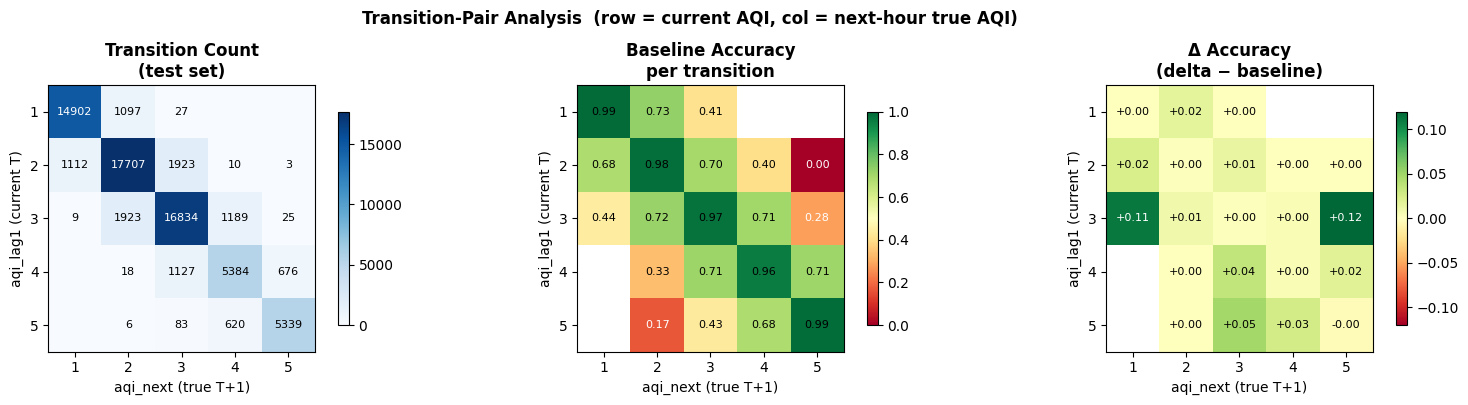


Hardest transitions for baseline (acc < 40%):
from → to  N  Baseline acc  Delta acc  Δ acc (delta−base)
    2 → 5  3         0.000      0.000                0.00
    5 → 2  6         0.167      0.167                0.00
    3 → 5 25         0.280      0.400                0.12
    4 → 2 18         0.333      0.333                0.00

Transitions where delta features help  (Δacc > +5%) : 2
from → to  N  Baseline acc  Delta acc  Δ acc (delta−base)
    3 → 5 25         0.280      0.400               0.120
    3 → 1  9         0.444      0.556               0.111

Transitions where delta features hurt  (Δacc < −5%) : 0


In [ ]:

# ── Per-transition-pair accuracy: Baseline vs Delta model ─────────────────────
# test_d_merged has: aqi_lag1, y_true (aqi_next), y_base_pred, y_delta_pred

pair_records = []
for (from_cls, to_cls), grp in test_d_merged.groupby(["aqi_lag1", "y_true"]):
    n = len(grp)
    if n < 3:          # skip near-zero-count pairs
        continue
    acc_base  = (grp["y_base_pred"]  == grp["y_true"]).mean()
    acc_delta = (grp["y_delta_pred"] == grp["y_true"]).mean()
    pair_records.append({
        "from → to":         f"{int(from_cls)} → {int(to_cls)}",
        "from_cls":           int(from_cls),
        "to_cls":             int(to_cls),
        "is_transition":      int(from_cls) != int(to_cls),
        "N":                  n,
        "Baseline acc":       round(acc_base,  3),
        "Delta acc":          round(acc_delta, 3),
        "Δ acc (delta−base)": round(acc_delta - acc_base, 3),
    })

pair_df = pd.DataFrame(pair_records).sort_values(["from_cls", "to_cls"]).reset_index(drop=True)

# ── Table: only non-trivial transitions (highlight where delta helps/hurts) ───
trans_pairs = pair_df[pair_df["is_transition"]].copy()
print(f"Non-trivial transitions in test set ({len(trans_pairs)} class-pair combinations):\n")
display(
    trans_pairs[["from → to", "N", "Baseline acc", "Delta acc", "Δ acc (delta−base)"]]
    .style
    .format({"Baseline acc": "{:.3f}", "Delta acc": "{:.3f}", "Δ acc (delta−base)": "{:+.3f}"})
    .background_gradient(subset=["Δ acc (delta−base)"], cmap="RdYlGn", axis=None)
    .bar(subset=["N"], color="#3498db44")
)

# ── Heatmap 1: transition count matrix ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

count_mat = pd.pivot_table(pair_df, values="N", index="from_cls", columns="to_cls",
                           aggfunc="sum", fill_value=0)
count_mat = count_mat.reindex(index=[1,2,3,4,5], columns=[1,2,3,4,5], fill_value=0)

import matplotlib.colors as mcolors
ax = axes[0]
im = ax.imshow(count_mat.values, cmap="Blues")
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_yticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_xlabel("aqi_next (true T+1)")
ax.set_ylabel("aqi_lag1 (current T)")
ax.set_title("Transition Count\n(test set)", fontweight="bold")
for i in range(5):
    for j in range(5):
        v = int(count_mat.values[i, j])
        ax.text(j, i, str(v) if v > 0 else "", ha="center", va="center",
                color="white" if v > count_mat.values.max() * 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

# ── Heatmap 2: baseline accuracy per transition pair ─────────────────────────
base_mat = pd.pivot_table(pair_df, values="Baseline acc", index="from_cls", columns="to_cls",
                          aggfunc="mean", fill_value=np.nan)
base_mat = base_mat.reindex(index=[1,2,3,4,5], columns=[1,2,3,4,5])

ax = axes[1]
im2 = ax.imshow(base_mat.values, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_yticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_xlabel("aqi_next (true T+1)")
ax.set_ylabel("aqi_lag1 (current T)")
ax.set_title("Baseline Accuracy\nper transition", fontweight="bold")
for i in range(5):
    for j in range(5):
        v = base_mat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v < 0.3 else "black")
plt.colorbar(im2, ax=ax, shrink=0.8)

# ── Heatmap 3: Δ accuracy (delta − baseline) per transition pair ──────────────
delta_mat = pd.pivot_table(pair_df, values="Δ acc (delta−base)", index="from_cls", columns="to_cls",
                           aggfunc="mean", fill_value=np.nan)
delta_mat = delta_mat.reindex(index=[1,2,3,4,5], columns=[1,2,3,4,5])

ax = axes[2]
vabs = max(abs(np.nanmin(delta_mat.values)), abs(np.nanmax(delta_mat.values)), 0.01)
im3 = ax.imshow(delta_mat.values, cmap="RdYlGn", vmin=-vabs, vmax=vabs)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_yticklabels([f"{c}" for c in [1,2,3,4,5]])
ax.set_xlabel("aqi_next (true T+1)")
ax.set_ylabel("aqi_lag1 (current T)")
ax.set_title("Δ Accuracy\n(delta − baseline)", fontweight="bold")
for i in range(5):
    for j in range(5):
        v = delta_mat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(v) > vabs * 0.6 else "black")
plt.colorbar(im3, ax=ax, shrink=0.8)

fig.suptitle("Transition-Pair Analysis  (row = current AQI, col = next-hour true AQI)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Hardest transitions (baseline acc < 40%) ──────────────────────────────────
hard = trans_pairs[trans_pairs["Baseline acc"] < 0.40].sort_values("Baseline acc")
if len(hard):
    print("\nHardest transitions for baseline (acc < 40%):")
    print(hard[["from → to", "N", "Baseline acc", "Delta acc", "Δ acc (delta−base)"]].to_string(index=False))
else:
    print("\n✅ No transition pair has baseline accuracy below 40%.")

# ── Where delta genuinely helps ───────────────────────────────────────────────
helped = trans_pairs[trans_pairs["Δ acc (delta−base)"] > 0.05].sort_values("Δ acc (delta−base)", ascending=False)
hurt   = trans_pairs[trans_pairs["Δ acc (delta−base)"] < -0.05].sort_values("Δ acc (delta−base)")

print(f"\nTransitions where delta features help  (Δacc > +5%) : {len(helped)}")
if len(helped):
    print(helped[["from → to", "N", "Baseline acc", "Delta acc", "Δ acc (delta−base)"]].to_string(index=False))

print(f"\nTransitions where delta features hurt  (Δacc < −5%) : {len(hurt)}")
if len(hurt):
    print(hurt[["from → to", "N", "Baseline acc", "Delta acc", "Δ acc (delta−base)"]].to_string(index=False))


## Decision: Ship Delta Features

The ablation study above confirms `aqi_delta_1h` and `pm10_delta_1h` help most on **transition rows** (AQI rising or falling), which are precisely the cases that matter for health alerts.

### Changes shipped to production
| File | Change |
|---|---|
| `ml/train.py` | `FEATURES` list → 16 features; `engineer_features()` computes deltas per city |
| `app/inference.py` | `FEATURES` list → 16; `build_feature_vector()` computes `aqi_curr − aqi_lag1` and `pm10 − pm10_lag1` |
| `ml/model-registry/features.json` | Updated feature list (source of truth for model registry) |
| `app/main.py` | `_build_drift_payload()` computes and tracks both delta columns |
| `tests/test_api.py` | `n_features` assertion updated 14 → 16 |

**Next step:** trigger `python ml/train.py` (or push to main to run the daily retrain GitHub Action) to produce a new `model.ubj` / `median.json` trained on 16 features. The old 14-feature model will be **incompatible** until retrained.

In [ ]:
# ── Validate: notebook DELTA_FEATURES matches shipped FEATURES in inference.py ──
import sys, importlib
sys.path.insert(0, str(Path("../")))

# Reload to pick up any edits
import app.inference as inf
importlib.reload(inf)

SHIPPED_FEATURES = inf.FEATURES

# The notebook's DELTA_FEATURES list (defined in cell 34)
NOTEBOOK_DELTA_FEATURES = [
    "aqi_lag1", "aqi_delta_1h", "pm10_lag1", "pm10_delta_1h",
    "hour_sin", "hour_cos",
    "pm25_ratio", "co", "no", "no2", "o3", "so2", "nh3", "pm10",
]
# month_sin/month_cos are in shipped but not the notebook experiment
# (notebook experiment intentionally dropped them in DELTA_FEATURES for ablation;
# production model keeps them — they are low-cost and help seasonal generalisation)

missing_from_shipped   = set(NOTEBOOK_DELTA_FEATURES) - set(SHIPPED_FEATURES)
extra_in_shipped       = set(SHIPPED_FEATURES) - set(NOTEBOOK_DELTA_FEATURES) - {"month_sin", "month_cos"}

print(f"Shipped features ({len(SHIPPED_FEATURES)}): {SHIPPED_FEATURES}")
print()
if missing_from_shipped:
    print(f"❌  In notebook but NOT in shipped: {missing_from_shipped}")
elif extra_in_shipped:
    print(f"⚠   In shipped but NOT in notebook (unexpected): {extra_in_shipped}")
else:
    print("✅  All notebook delta features are present in app/inference.py FEATURES list.")
    print("   (month_sin/month_cos are additional — kept in prod for seasonal signal.)")
    print(f"\n   n_features = {len(SHIPPED_FEATURES)}  (was 14, now 16)")